In [1]:
from pathlib import Path

In [2]:
modern_text = Path("ctl-modernist-fiction/clean00001261.txt").read_text(encoding="utf-8")

In [3]:
len(modern_text)

447440

In [4]:
print(modern_text[:500])

This etext was prepared from the 1896 Fredericke Warne & Co. edition by David Price, email ccx074@coventry.ac.uk A LADY OF QUALITY Being a most curious, hitherto unknown history, as related by Mr. Isaac Bickerstaff but not presented to the World of Fashion through the pages of The Tatler, and now for the first time written down by Francis Hodgson Burnett Were Nature just to Man from his first hour, he need not ask for Mercy; then 'tis for us--the toys of Nature--to be both just and merciful, for


In [5]:
nonmodern_text = Path("1895-1926-ctl-american-non-modernist/clean00001142.txt").read_text(encoding="utf-8")

In [6]:
len(nonmodern_text)

178285

In [7]:
import nltk

In [8]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to D:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
from nltk.tokenize import word_tokenize

In [10]:
modern_tokens = word_tokenize(modern_text)

In [11]:
len(modern_tokens)

99884

In [12]:
modern_tokens[:30]

['This',
 'etext',
 'was',
 'prepared',
 'from',
 'the',
 '1896',
 'Fredericke',
 'Warne',
 '&',
 'Co.',
 'edition',
 'by',
 'David',
 'Price',
 ',',
 'email',
 'ccx074',
 '@',
 'coventry.ac.uk',
 'A',
 'LADY',
 'OF',
 'QUALITY',
 'Being',
 'a',
 'most',
 'curious',
 ',',
 'hitherto']

In [13]:
nonmodern_tokens = word_tokenize(nonmodern_text)

In [14]:
len(nonmodern_tokens)

38962

In [15]:
# Clean: keep text starting from Chapter I
modern_start = modern_text.find("CHAPTER I")
nonmodern_start = nonmodern_text.find("CHAPTER I")

if modern_start != -1:
    modern_text_clean = modern_text[modern_start:]
else:
    modern_text_clean = modern_text

if nonmodern_start != -1:
    nonmodern_text_clean = nonmodern_text[nonmodern_start:]
else:
    nonmodern_text_clean = nonmodern_text

In [16]:
modern_tokens = word_tokenize(modern_text_clean)
nonmodern_tokens = word_tokenize(nonmodern_text_clean)

In [17]:
modern_tokens[:30]

['CHAPTER',
 'I',
 '--',
 'The',
 'twenty-fourth',
 'day',
 'of',
 'November',
 '1690',
 'On',
 'a',
 'wintry',
 'morning',
 'at',
 'the',
 'close',
 'of',
 '1690',
 ',',
 'the',
 'sun',
 'shining',
 'faint',
 'and',
 'red',
 'through',
 'a',
 'light',
 'fog',
 ',']

In [18]:
nonmodern_tokens[:30]

['CHAPTER',
 'I',
 ':',
 'CORSICA',
 'TO',
 'BRIENNE',
 '1769-1779',
 'Napoleon',
 "'s",
 'father',
 ',',
 'Charles',
 'Bonaparte',
 ',',
 'was',
 'the',
 'honored',
 'progenitor',
 'of',
 'thirteen',
 'children',
 ',',
 'of',
 'whom',
 'the',
 'man',
 'who',
 'subsequently',
 'became',
 'the']

In [19]:
modern_tokens = [word.lower() for word in modern_tokens]
nonmodern_tokens = [word.lower() for word in nonmodern_tokens]

In [20]:
modern_words = [word for word in modern_tokens if word.isalpha()]
nonmodern_words = [word for word in nonmodern_tokens if word.isalpha()]

In [21]:
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to D:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
modern_words = [
    word
    for word in modern_words
    if word not in stop_words
]

nonmodern_words = [
    word
    for word in nonmodern_words
    if word not in stop_words
]

In [23]:
print(len(modern_words))
print(len(nonmodern_words))

37783
14630


In [24]:
modern_words[:30]

['chapter',
 'day',
 'november',
 'wintry',
 'morning',
 'close',
 'sun',
 'shining',
 'faint',
 'red',
 'light',
 'fog',
 'great',
 'noise',
 'baying',
 'dogs',
 'loud',
 'voices',
 'trampling',
 'horses',
 'wildairs',
 'hall',
 'sir',
 'jeoffry',
 'go',
 'forth',
 'man',
 'choleric',
 'temper',
 'big']

### Removing Stopwords

For this repetition analysis, I removed common English stopwords and kept alphabetic content words. This lets me focus on repeated nouns, verbs, adjectives, and other content words. I kept in mind that removing stopwords also removes some information about syntax and sentence structure.

In [25]:
from nltk import FreqDist

modern_fdist = FreqDist(modern_words)
nonmodern_fdist = FreqDist(nonmodern_words)

modern_fdist.most_common(20)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147)]

In [26]:
nonmodern_fdist.most_common(20)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48)]

In [27]:
print("Top 30 words after removing stopwords")

modern_fdist.most_common(30)

Top 30 words after removing stopwords


[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147),
 ('thing', 146),
 ('seemed', 144),
 ('hand', 137),
 ('little', 136),
 ('beauty', 136),
 ('might', 135),
 ('come', 128),
 ('sister', 128),
 ('even', 127),
 ('back', 119)]

In [28]:
nonmodern_fdist.most_common(30)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48),
 ('shall', 47),
 ('good', 46),
 ('france', 46),
 ('new', 46),
 ('made', 45),
 ('get', 45),
 ('must', 45),
 ('first', 44),
 ('french', 43),
 ('make', 43)]

In [29]:
len(modern_words), len(nonmodern_words)

(37783, 14630)

In [30]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        
        positions[word].append(index)
    
    return positions

In [31]:
modern_positions = get_word_positions(modern_words)
nonmodern_positions = get_word_positions(nonmodern_words)

In [32]:
modern_positions["horse"][:20]

[126,
 317,
 378,
 439,
 1408,
 1968,
 2012,
 2056,
 2145,
 2166,
 2192,
 2933,
 2936,
 2942,
 2945,
 2947,
 2965,
 3063,
 3084,
 3257]

In [33]:
modern_positions["child"][:20]

[205,
 482,
 504,
 542,
 557,
 837,
 877,
 879,
 900,
 1025,
 1118,
 1331,
 1365,
 1421,
 1486,
 1520,
 1596,
 2293,
 2427,
 2828]

In [34]:
def repetition_distances(position_list):
    distances = []

    for i in range(len(position_list) - 1):
        distance = position_list[i + 1] - position_list[i]
        distances.append(distance)

    return distances

In [35]:
repetition_distances([3, 10, 15, 30])

[7, 5, 15]

In [36]:
horse_distances = repetition_distances(modern_positions["horse"])

horse_distances[:30]

[191,
 61,
 61,
 969,
 560,
 44,
 44,
 89,
 21,
 26,
 741,
 3,
 6,
 3,
 2,
 18,
 98,
 21,
 173,
 231,
 488,
 4294,
 2604,
 626,
 4124,
 19,
 133,
 86,
 4602,
 466]

In [37]:
child_distances = repetition_distances(modern_positions["child"])

child_distances[:30]

[277,
 22,
 38,
 15,
 280,
 40,
 2,
 21,
 125,
 93,
 213,
 34,
 56,
 65,
 34,
 76,
 697,
 134,
 401,
 293,
 116,
 126,
 58,
 187,
 53,
 321,
 146,
 3832,
 75,
 1085]

In [38]:
def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [39]:
average_distance([3, 10, 15, 30])

9.0

In [40]:
average_distance(modern_positions["child"])

498.3066666666667

In [41]:
import statistics

def repetition_summary(word, positions):
    if word not in positions:
        print(word, "does not appear in this text.")
        return
    
    pos = positions[word]
    distances = repetition_distances(pos)
    avg_dist = average_distance(pos)
    
    if len(distances) == 0:
        median_dist = None
    else:
        median_dist = statistics.median(distances)
    
    print("Word:", word)
    print("Number of occurrences:", len(pos))
    print("First 30 positions:", pos[:30])
    print("First 30 repetition distances:", distances[:30])
    print("Average repetition distance:", avg_dist)
    print("Median repetition distance:", median_dist)

In [42]:
repetition_summary("horse", modern_positions)

Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95


In [43]:
repetition_summary("child", modern_positions)

Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 280, 40, 2, 21, 125, 93, 213, 34, 56, 65, 34, 76, 697, 134, 401, 293, 116, 126, 58, 187, 53, 321, 146, 3832, 75, 1085]
Average repetition distance: 498.3066666666667
Median repetition distance: 126


In [44]:
"horse" in nonmodern_positions, "child" in nonmodern_positions

(True, True)

In [45]:
print("Modern text:")
repetition_summary("horse", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("horse", nonmodern_positions)

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [5225]
First 30 repetition distances: []
Average repetition distance: None
Median repetition distance: None


In [46]:
print("Modern text:")
repetition_summary("child", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("child", nonmodern_positions)

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 280, 40, 2, 21, 125, 93, 213, 34, 56, 65, 34, 76, 697, 134, 401, 293, 116, 126, 58, 187, 53, 321, 146, 3832, 75, 1085]
Average repetition distance: 498.3066666666667
Median repetition distance: 126

Nonmodern text:
Word: child
Number of occurrences: 6
First 30 positions: [44, 199, 357, 981, 1062, 7107]
First 30 repetition distances: [155, 158, 624, 81, 6045]
Average repetition distance: 1412.6
Median repetition distance: 158


In [47]:
modern_fdist.most_common(80)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147),
 ('thing', 146),
 ('seemed', 144),
 ('hand', 137),
 ('little', 136),
 ('beauty', 136),
 ('might', 135),
 ('come', 128),
 ('sister', 128),
 ('even', 127),
 ('back', 119),
 ('look', 117),
 ('knew', 117),
 ('never', 117),
 ('must', 115),
 ('came', 113),
 ('time', 109),
 ('young', 108),
 ('stood', 107),
 ('see', 104),
 ('god', 102),
 ('life', 100),
 ('know', 99),
 ('went', 98),
 ('indeed', 97),
 ('way', 97),
 ('dunstanwolde', 97),
 ('lord', 95),
 ('thought', 93),
 ('well', 92),
 ('cried', 92),
 ('first', 91),
 ('john', 91),
 ('saw', 90),
 ('day', 89),
 ('looked', 88),
 ('night', 85),
 ('ever', 85),
 ('away', 82),
 ('strange', 82),
 ('head', 81),
 ('lay', 80),
 ('je

In [48]:
words_to_compare = ["horse", "child", "woman", "man", "house", "room", "eyes", "hand", "day", "time"]

In [49]:
for word in words_to_compare:
    print("====================")
    print("WORD:", word)
    print()
    
    print("Modern text:")
    repetition_summary(word, modern_positions)
    print()
    
    print("Nonmodern text:")
    repetition_summary(word, nonmodern_positions)
    print()

WORD: horse

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [5225]
First 30 repetition distances: []
Average repetition distance: None
Median repetition distance: None

WORD: child

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 

In [50]:
def normalized_frequency(word, words):
    count = words.count(word)
    return count / len(words) * 1000

In [51]:
normalized_frequency("horse", modern_words)

1.2704126194320196

In [52]:
normalized_frequency("horse", nonmodern_words)

0.06835269993164729

In [53]:
def compare_word(word):
    print("Word:", word)
    print()
    
    print("Modern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, modern_words))
    
    if word in modern_positions:
        print("Average repetition distance:", average_distance(modern_positions[word]))
    else:
        print("Average repetition distance: None")
    
    print()
    
    print("Nonmodern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, nonmodern_words))
    
    if word in nonmodern_positions:
        print("Average repetition distance:", average_distance(nonmodern_positions[word]))
    else:
        print("Average repetition distance: None")

In [54]:
def all_repetition_distances(positions):
    all_distances = []
    
    for word in positions:
        distances = repetition_distances(positions[word])
        all_distances.extend(distances)
    
    return all_distances

In [55]:
def text_style_features(words, positions):
    total_words = len(words)
    vocabulary_size = len(set(words))
    type_token_ratio = vocabulary_size / total_words
    
    repeated_words = []
    for word in positions:
        if len(positions[word]) > 1:
            repeated_words.append(word)
    
    repeated_word_ratio = len(repeated_words) / vocabulary_size
    
    distances = all_repetition_distances(positions)
    
    if len(distances) == 0:
        average_rep_distance = None
        median_rep_distance = None
    else:
        average_rep_distance = sum(distances) / len(distances)
        median_rep_distance = statistics.median(distances)
    
    print("Total words:", total_words)
    print("Vocabulary size:", vocabulary_size)
    print("Type-token ratio:", type_token_ratio)
    print("Repeated word count:", len(repeated_words))
    print("Repeated word ratio:", repeated_word_ratio)
    print("Average repetition distance:", average_rep_distance)
    print("Median repetition distance:", median_rep_distance)

In [56]:
compare_word("horse")

Word: horse

Modern text:
Frequency per 1000 words: 1.2704126194320196
Average repetition distance: 585.5531914893617

Nonmodern text:
Frequency per 1000 words: 0.06835269993164729
Average repetition distance: None


In [57]:
print("Modern text style features")
print("==========================")
text_style_features(modern_words, modern_positions)

Modern text style features
Total words: 37783
Vocabulary size: 5983
Type-token ratio: 0.15835163962628696
Repeated word count: 3297
Repeated word ratio: 0.5510613404646498
Average repetition distance: 2022.4701257861636
Median repetition distance: 478.0


In [58]:
print("Nonmodern text style features")
print("=============================")
text_style_features(nonmodern_words, nonmodern_positions)

Nonmodern text style features
Total words: 14630
Vocabulary size: 4537
Type-token ratio: 0.3101161995898838
Repeated word count: 2011
Repeated word ratio: 0.4432444346484461
Average repetition distance: 1336.7358565342317
Median repetition distance: 426


In [59]:
compare_word("child")

Word: child

Modern text:
Frequency per 1000 words: 2.011486647434031
Average repetition distance: 498.3066666666667

Nonmodern text:
Frequency per 1000 words: 0.4101161995898838
Average repetition distance: 1412.6


In [60]:
compare_word("woman")

Word: woman

Modern text:
Frequency per 1000 words: 6.060926871873594
Average repetition distance: 164.18421052631578

Nonmodern text:
Frequency per 1000 words: 0.9569377990430622
Average repetition distance: 1074.3846153846155


In [61]:
print(
    f'{"Word":<10} {"Modern Freq":>12} {"Nonmodern Freq":>15} {"Modern Dist":>15} {"Nonmodern Dist":>18}'
)

print("-" * 75)

for word in words_to_compare:

    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    print(
        f"{word:<10} {modern_freq:>12.2f} {nonmodern_freq:>15.2f} {str(round(modern_dist,2)) if modern_dist else 'None':>15} {str(round(nonmodern_dist,2)) if nonmodern_dist else 'None':>18}"
    )

Word        Modern Freq  Nonmodern Freq     Modern Dist     Nonmodern Dist
---------------------------------------------------------------------------
horse              1.27            0.07          585.55               None
child              2.01            0.41          498.31             1412.6
woman              6.06            0.96          164.18            1074.38
man                6.33            4.24          158.33             235.98
house              1.93            0.62          486.29            1664.62
room               1.43            0.62          695.89            1500.25
eyes               5.98            0.41          165.95             2211.8
hand               3.63            1.23          273.74             764.18
day                2.36            2.46          427.16             411.83
time               2.88            4.37          324.02              224.6


In [62]:
from pathlib import Path

modern_folder = Path("ctl-modernist-fiction")
nonmodern_folder = Path("1895-1926-ctl-american-non-modernist")

modern_files = list(modern_folder.glob("*.txt"))
nonmodern_files = list(nonmodern_folder.glob("*.txt"))

len(modern_files), len(nonmodern_files)

(41, 984)

In [63]:
modern_files_sample = modern_files[:10]
nonmodern_files_sample = nonmodern_files[:10]

modern_files_sample, nonmodern_files_sample

([WindowsPath('ctl-modernist-fiction/clean00001261.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001690.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001828.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001884.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002304.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002437.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002725.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002948.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002949.txt'),
  WindowsPath('ctl-modernist-fiction/clean00003082.txt')],
 [WindowsPath('1895-1926-ctl-american-non-modernist/clean00001142.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001156.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001160.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001161.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001162.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/cl

In [64]:
from nltk.tokenize import word_tokenize

def read_and_tokenize(file_path):
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    
    start = text.find("CHAPTER I")
    if start != -1:
        text = text[start:]
    
    tokens = word_tokenize(text)
    words = [word.lower() for word in tokens if word.isalpha()]
    
    return words

In [65]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        positions[word].append(index)
    
    return positions


def repetition_distances(position_list):
    distances = []
    
    for i in range(len(position_list) - 1):
        distances.append(position_list[i + 1] - position_list[i])
    
    return distances


def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [66]:
def text_repetition_features(file_path, label):
    words = read_and_tokenize(file_path)
    positions = get_word_positions(words)
    
    repeated_words = [word for word in positions if len(positions[word]) >= 2]
    
    repetition_rate = len(repeated_words) / len(set(words))
    
    all_distances = []
    for word in repeated_words:
        all_distances.extend(repetition_distances(positions[word]))
    
    if len(all_distances) > 0:
        avg_repetition_distance = sum(all_distances) / len(all_distances)
    else:
        avg_repetition_distance = None
    
    return {
        "file": file_path.name,
        "label": label,
        "total_words": len(words),
        "unique_words": len(set(words)),
        "repeated_words": len(repeated_words),
        "repetition_rate": repetition_rate,
        "avg_repetition_distance": avg_repetition_distance
    }

In [68]:
import pandas as pd

rows = []

for file in modern_files_sample:
    rows.append(text_repetition_features(file, "modernist"))

for file in nonmodern_files_sample:
    rows.append(text_repetition_features(file, "nonmodernist"))

df = pd.DataFrame(rows)

In [69]:
df.groupby("label")[[
    "total_words",
    "unique_words",
    "repeated_words",
    "repetition_rate",
    "avg_repetition_distance"
]].mean()

,total_words,unique_words,repeated_words,repetition_rate,avg_repetition_distance
label,,,,,
modernist,83132.0,7077.0,3751.6,0.51114,2196.201498
nonmodernist,67055.1,6467.1,3357.7,0.51197,1940.227861


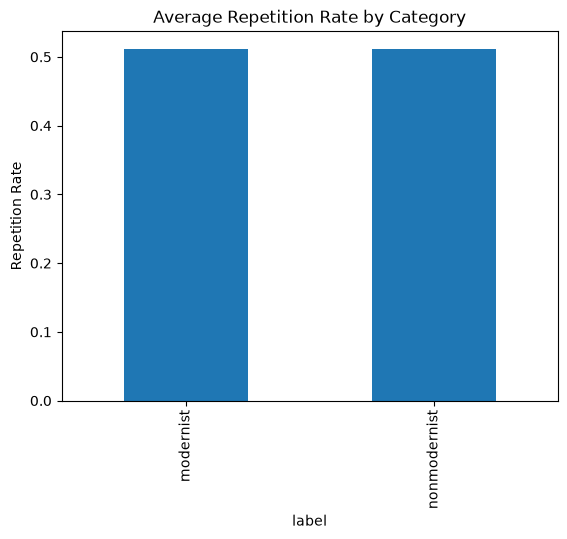

In [70]:
import matplotlib.pyplot as plt

df.groupby("label")["repetition_rate"].mean().plot(kind="bar")

plt.title("Average Repetition Rate by Category")
plt.ylabel("Repetition Rate")
plt.show()

In [71]:
from nltk import ConditionalFreqDist

text_word_pairs = []

for word in modern_words:
    text_word_pairs.append(("modern", word))

for word in nonmodern_words:
    text_word_pairs.append(("nonmodern", word))

cfd = ConditionalFreqDist(text_word_pairs)

In [72]:
cfd["modern"].most_common(20)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147)]

In [73]:
cfd["nonmodern"].most_common(20)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48)]

### Comparing the Two Texts with ConditionalFreqDist

I used `ConditionalFreqDist` to store frequencies under two labels, `modern` and `nonmodern`. This makes it easier to compare the same word across the two texts.

In [74]:
candidate_words = []

for word in modern_fdist:
    if modern_fdist[word] >= 20 and nonmodern_fdist[word] >= 1:
        candidate_words.append(word)

candidate_words = sorted(candidate_words)

len(candidate_words)

316

In [75]:
def word_feature_row(word):
    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    return [word, modern_freq, nonmodern_freq, modern_dist, nonmodern_dist]

In [76]:
feature_rows = []

for word in candidate_words:
    feature_rows.append(word_feature_row(word))

feature_rows[:10]

[['air', 1.0057433237170155, 0.27341079972658916, 956.1351351351351, 2138.0],
 ['almost', 1.6938834925760262, 0.06835269993164729, 555.2063492063492, None],
 ['alone', 1.164544901146018, 0.34176349965823655, 835.6976744186046, 3057.75],
 ['also', 0.9263425350025143, 0.6151742993848256, 1030.764705882353, 1567.375],
 ['always',
  1.29687954900352,
  1.3670539986329462,
  726.7708333333334,
  738.6842105263158],
 ['among', 1.6409496334330256, 0.13670539986329458, 576.7540983606557, 8848.0],
 ['another',
  1.1116110420030172,
  1.3670539986329462,
  907.8780487804878,
  690.421052631579],
 ['answer',
  0.6352063097160098,
  0.2050580997949419,
  1617.8260869565217,
  6220.0],
 ['arm', 0.6616732392875103, 0.13670539986329458, 1443.0, 986.0],
 ['arms', 0.8734086758595135, 0.4784688995215311, 1129.15625, 1942.0]]

In [77]:
import pandas as pd

features_df = pd.DataFrame(
    feature_rows,
    columns=[
        "word",
        "modern_freq_per_1000",
        "nonmodern_freq_per_1000",
        "modern_avg_distance",
        "nonmodern_avg_distance"
    ]
)

features_df.head()

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance
0,air,1.005743,0.273411,956.135135,2138.000000
1,almost,1.693883,0.068353,555.206349,NaN
2,alone,1.164545,0.341763,835.697674,3057.750000
3,also,0.926343,0.615174,1030.764706,1567.375000
4,always,1.296880,1.367054,726.770833,738.684211


In [78]:
features_df["frequency_difference"] = (
    features_df["modern_freq_per_1000"] 
    - features_df["nonmodern_freq_per_1000"]
)

features_df.sort_values("frequency_difference", ascending=False).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
65,eyes,5.981526,0.410116,165.946667,2211.800000,5.571410
303,woman,6.060927,0.956938,164.184211,1074.384615,5.103989
310,would,10.427970,5.468216,93.893130,173.683544,4.959754
133,lady,4.711113,0.136705,211.480226,503.000000,4.574408
99,great,6.219728,2.460697,161.059829,400.257143,3.759031
241,sir,4.049440,0.546822,231.197368,1033.142857,3.502619
16,beauty,3.599502,0.136705,253.140741,3501.000000,3.462797
230,seemed,3.811238,0.478469,258.237762,2004.000000,3.332769
207,poor,3.996506,0.683527,249.433333,1352.111111,3.312979
290,upon,7.278406,4.032809,136.777372,242.603448,3.245596


The frequency difference shows which words occur more often in one text after normalization. Because my main question concerns repetition patterns rather than frequency alone, I also calculate the distance between consecutive occurrences.

In [79]:
modern_repetition_candidates = features_df[
    (features_df["modern_freq_per_1000"] > features_df["nonmodern_freq_per_1000"]) &
    (features_df["modern_avg_distance"] < features_df["nonmodern_avg_distance"])
]

modern_repetition_candidates.sort_values(
    "frequency_difference", 
    ascending=False
).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
65,eyes,5.981526,0.410116,165.946667,2211.800000,5.571410
303,woman,6.060927,0.956938,164.184211,1074.384615,5.103989
310,would,10.427970,5.468216,93.893130,173.683544,4.959754
133,lady,4.711113,0.136705,211.480226,503.000000,4.574408
99,great,6.219728,2.460697,161.059829,400.257143,3.759031
241,sir,4.049440,0.546822,231.197368,1033.142857,3.502619
16,beauty,3.599502,0.136705,253.140741,3501.000000,3.462797
230,seemed,3.811238,0.478469,258.237762,2004.000000,3.332769
207,poor,3.996506,0.683527,249.433333,1352.111111,3.312979
290,upon,7.278406,4.032809,136.777372,242.603448,3.245596


In [80]:
def split_into_chunks(words, chunk_size=1000):
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = words[i:i + chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

In [81]:
modern_chunks = split_into_chunks(modern_words, 1000)
nonmodern_chunks = split_into_chunks(nonmodern_words, 1000)

len(modern_chunks), len(nonmodern_chunks)

(37, 14)

In [82]:
def chunk_repetition_features(chunk):
    freq = FreqDist(chunk)

    repeated_words = [word for word in freq if freq[word] > 1]

    repeated_word_count = len(repeated_words)
    total_repetition_count = sum(freq[word] - 1 for word in repeated_words)
    unique_ratio = len(set(chunk)) / len(chunk)

    return {
        "repeated_word_count": repeated_word_count,
        "total_repetition_count": total_repetition_count,
        "unique_ratio": unique_ratio
    }

In [83]:
chunk_repetition_features(modern_chunks[0])

{'repeated_word_count': 181,
 'total_repetition_count': 390,
 'unique_ratio': 0.61}

In [84]:
rows = []

for chunk in modern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "modern"
    rows.append(features)

for chunk in nonmodern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "nonmodern"
    rows.append(features)

chunk_df = pd.DataFrame(rows)
chunk_df.head()

,repeated_word_count,total_repetition_count,unique_ratio,label
0,181,390,0.610,modern
1,180,373,0.627,modern
2,171,391,0.609,modern
3,166,329,0.671,modern
4,160,369,0.631,modern


In [85]:
chunk_df.groupby("label").mean()

,repeated_word_count,total_repetition_count,unique_ratio
label,,,
modern,174.351351,394.108108,0.605892
nonmodern,155.214286,340.428571,0.659571


<Axes: xlabel='label'>

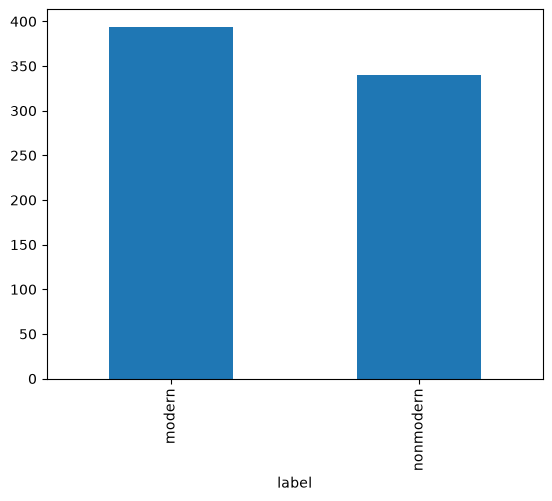

In [86]:
chunk_df.groupby("label")["total_repetition_count"].mean().plot(kind="bar")

In [87]:
def word_style_features(word, words, positions):
    result = {}

    result["Word"] = word
    result["Occurrences"] = words.count(word)
    result["Frequency per 1000 words"] = normalized_frequency(word, words)

    if word in positions:
        result["Average repetition distance"] = average_distance(positions[word])
    else:
        result["Average repetition distance"] = None

    return result

In [88]:
word_style_features("child", modern_words, modern_positions)

{'Word': 'child',
 'Occurrences': 76,
 'Frequency per 1000 words': 2.011486647434031,
 'Average repetition distance': 498.3066666666667}

In [89]:
import pandas as pd

In [90]:
interesting_words = [
    "child",
    "woman",
    "man",
    "eyes",
    "hand",
    "house",
    "room",
    "day",
    "time"
]

In [91]:
modern_results = []

for word in interesting_words:
    features = word_style_features(
        word,
        modern_words,
        modern_positions
    )

    modern_results.append(features)

modern_df = pd.DataFrame(modern_results)

modern_df

,Word,Occurrences,Frequency per 1000 words,Average repetition distance
0,child,76,2.011487,498.306667
1,woman,229,6.060927,164.184211
2,man,239,6.325596,158.327731
3,eyes,226,5.981526,165.946667
4,hand,137,3.625969,273.742647
5,house,73,1.932086,486.291667
6,room,54,1.429214,695.886792
7,day,89,2.355557,427.159091
8,time,109,2.884895,324.018519


In [92]:
nonmodern_results = []

for word in interesting_words:
    features = word_style_features(
        word,
        nonmodern_words,
        nonmodern_positions
    )

    nonmodern_results.append(features)

nonmodern_df = pd.DataFrame(nonmodern_results)

nonmodern_df

,Word,Occurrences,Frequency per 1000 words,Average repetition distance
0,child,6,0.410116,1412.600000
1,woman,14,0.956938,1074.384615
2,man,62,4.237867,235.983607
3,eyes,6,0.410116,2211.800000
4,hand,18,1.230349,764.176471
5,house,9,0.615174,1664.625000
6,room,9,0.615174,1500.250000
7,day,36,2.460697,411.828571
8,time,64,4.374573,224.603175


## Text-Level Repetition Features

The earlier cells measured selected words separately. Here I calculate summary features for the complete cleaned text. The purpose is to represent each text with the same set of numerical measurements.

In [93]:
def collect_all_repetition_distances(positions):
    all_distances = []

    for word, position_list in positions.items():
        if len(position_list) >= 2:
            distances = repetition_distances(position_list)
            all_distances.extend(distances)

    return all_distances

In [94]:
modern_all_distances = collect_all_repetition_distances(modern_positions)

len(modern_all_distances)

31800

In [95]:
modern_all_distances[:30]

[1141,
 1580,
 1332,
 1834,
 1643,
 1747,
 1455,
 2313,
 960,
 1160,
 2157,
 1141,
 1996,
 2206,
 1817,
 1917,
 1933,
 831,
 1779,
 1084,
 1782,
 735,
 1370,
 47,
 6,
 31,
 1108,
 1,
 757,
 37]

In [96]:
nonmodern_all_distances = collect_all_repetition_distances(nonmodern_positions)

len(nonmodern_all_distances)

10093

In [97]:
def short_repetition_ratio(distances, threshold):
    if len(distances) == 0:
        return 0

    short_distances = [
        distance
        for distance in distances
        if distance <= threshold
    ]

    return len(short_distances) / len(distances)

In [98]:
short_repetition_ratio([2, 5, 10, 30, 100], 10)

0.6

In [99]:
def text_repetition_features(words, positions):
    total_words = len(words)
    vocabulary_size = len(positions)

    repeated_words = {
        word: position_list
        for word, position_list in positions.items()
        if len(position_list) >= 2
    }

    repeated_word_types = len(repeated_words)

    all_distances = collect_all_repetition_distances(positions)

    occurrence_counts = [
        len(position_list)
        for position_list in repeated_words.values()
    ]

    if total_words == 0:
        type_token_ratio = 0
    else:
        type_token_ratio = vocabulary_size / total_words

    if vocabulary_size == 0:
        repeated_type_ratio = 0
    else:
        repeated_type_ratio = repeated_word_types / vocabulary_size

    if len(all_distances) == 0:
        mean_repetition_distance = None
        median_repetition_distance = None
    else:
        mean_repetition_distance = statistics.mean(all_distances)
        median_repetition_distance = statistics.median(all_distances)

    if len(occurrence_counts) == 0:
        mean_repeated_word_frequency = 0
        median_repeated_word_frequency = 0
    else:
        mean_repeated_word_frequency = statistics.mean(occurrence_counts)
        median_repeated_word_frequency = statistics.median(occurrence_counts)

    return {
        "Total words": total_words,
        "Vocabulary size": vocabulary_size,
        "Type-token ratio": type_token_ratio,
        "Repeated word types": repeated_word_types,
        "Repeated type ratio": repeated_type_ratio,
        "Mean repeated-word frequency": mean_repeated_word_frequency,
        "Median repeated-word frequency": median_repeated_word_frequency,
        "Mean repetition distance": mean_repetition_distance,
        "Median repetition distance": median_repetition_distance,
        "Repetition distance <= 5": short_repetition_ratio(
            all_distances,
            5
        ),
        "Repetition distance <= 20": short_repetition_ratio(
            all_distances,
            20
        ),
        "Repetition distance <= 100": short_repetition_ratio(
            all_distances,
            100
        )
    }

In [100]:
modern_text_features = text_repetition_features(
    modern_words,
    modern_positions
)

modern_text_features

{'Total words': 37783,
 'Vocabulary size': 5983,
 'Type-token ratio': 0.15835163962628696,
 'Repeated word types': 3297,
 'Repeated type ratio': 0.5510613404646498,
 'Mean repeated-word frequency': 10.64513193812557,
 'Median repeated-word frequency': 4,
 'Mean repetition distance': 2022.4701257861636,
 'Median repetition distance': 478.0,
 'Repetition distance <= 5': 0.028522012578616352,
 'Repetition distance <= 20': 0.08305031446540881,
 'Repetition distance <= 100': 0.24581761006289307}

In [101]:
nonmodern_text_features = text_repetition_features(
    nonmodern_words,
    nonmodern_positions
)

nonmodern_text_features

{'Total words': 14630,
 'Vocabulary size': 4537,
 'Type-token ratio': 0.3101161995898838,
 'Repeated word types': 2011,
 'Repeated type ratio': 0.4432444346484461,
 'Mean repeated-word frequency': 6.018896071606166,
 'Median repeated-word frequency': 3,
 'Mean repetition distance': 1336.7358565342317,
 'Median repetition distance': 426,
 'Repetition distance <= 5': 0.024868720895670268,
 'Repetition distance <= 20': 0.10660854057267413,
 'Repetition distance <= 100': 0.27494302982264934}

In [102]:
text_feature_df = pd.DataFrame([
    {
        "Text": "Modern",
        "Label": 1,
        **modern_text_features
    },
    {
        "Text": "Nonmodern",
        "Label": 0,
        **nonmodern_text_features
    }
])

text_feature_df

,Text,Label,Total words,Vocabulary size,Type-token ratio,Repeated word types,Repeated type ratio,Mean repeated-word frequency,Median repeated-word frequency,Mean repetition distance,Median repetition distance,Repetition distance <= 5,Repetition distance <= 20,Repetition distance <= 100
0,Modern,1,37783,5983,0.158352,3297,0.551061,10.645132,4,2022.470126,478.0,0.028522,0.083050,0.245818
1,Nonmodern,0,14630,4537,0.310116,2011,0.443244,6.018896,3,1336.735857,426.0,0.024869,0.106609,0.274943


In [103]:
comparison_df = text_feature_df.set_index("Text").drop(
    columns="Label"
).transpose()

comparison_df

Text,Modern,Nonmodern
Total words,37783.000000,14630.000000
Vocabulary size,5983.000000,4537.000000
Type-token ratio,0.158352,0.310116
Repeated word types,3297.000000,2011.000000
Repeated type ratio,0.551061,0.443244
Mean repeated-word frequency,10.645132,6.018896
Median repeated-word frequency,4.000000,3.000000
Mean repetition distance,2022.470126,1336.735857
Median repetition distance,478.000000,426.000000
Repetition distance <= 5,0.028522,0.024869


In [104]:
comparison_df.round(4)

Text,Modern,Nonmodern
Total words,37783.0000,14630.0000
Vocabulary size,5983.0000,4537.0000
Type-token ratio,0.1584,0.3101
Repeated word types,3297.0000,2011.0000
Repeated type ratio,0.5511,0.4432
Mean repeated-word frequency,10.6451,6.0189
Median repeated-word frequency,4.0000,3.0000
Mean repetition distance,2022.4701,1336.7359
Median repetition distance,478.0000,426.0000
Repetition distance <= 5,0.0285,0.0249


In [105]:
modern_text_features.keys() == nonmodern_text_features.keys()

True

In [106]:
feature_difference_df = comparison_df.copy()

feature_difference_df["Difference (Modern - Nonmodern)"] = (
    feature_difference_df["Modern"]
    - feature_difference_df["Nonmodern"]
)

feature_difference_df.round(4)

Text,Modern,Nonmodern,Difference (Modern - Nonmodern)
Total words,37783.0000,14630.0000,23153.0000
Vocabulary size,5983.0000,4537.0000,1446.0000
Type-token ratio,0.1584,0.3101,-0.1518
Repeated word types,3297.0000,2011.0000,1286.0000
Repeated type ratio,0.5511,0.4432,0.1078
Mean repeated-word frequency,10.6451,6.0189,4.6262
Median repeated-word frequency,4.0000,3.0000,1.0000
Mean repetition distance,2022.4701,1336.7359,685.7343
Median repetition distance,478.0000,426.0000,52.0000
Repetition distance <= 5,0.0285,0.0249,0.0037


In [107]:
normalized_features = [
    "Type-token ratio",
    "Repeated type ratio",
    "Mean repeated-word frequency",
    "Median repeated-word frequency",
    "Repetition distance <= 5",
    "Repetition distance <= 20",
    "Repetition distance <= 100"
]

comparison_df.loc[normalized_features].round(4)

Text,Modern,Nonmodern
Type-token ratio,0.1584,0.3101
Repeated type ratio,0.5511,0.4432
Mean repeated-word frequency,10.6451,6.0189
Median repeated-word frequency,4.0000,3.0000
Repetition distance <= 5,0.0285,0.0249
Repetition distance <= 20,0.0831,0.1066
Repetition distance <= 100,0.2458,0.2749


## Character and Punctuation Features

I also tested a small set of features based on characters and punctuation. For this part, I use tokens before alphabetic filtering because punctuation, capitalization, and digits must remain in the text.

In [108]:
from nltk.tokenize import word_tokenize

In [109]:
modern_all_tokens = word_tokenize(modern_text_clean)
nonmodern_all_tokens = word_tokenize(nonmodern_text_clean)

print(modern_all_tokens[:30])
print(nonmodern_all_tokens[:30])

['CHAPTER', 'I', '--', 'The', 'twenty-fourth', 'day', 'of', 'November', '1690', 'On', 'a', 'wintry', 'morning', 'at', 'the', 'close', 'of', '1690', ',', 'the', 'sun', 'shining', 'faint', 'and', 'red', 'through', 'a', 'light', 'fog', ',']
['CHAPTER', 'I', ':', 'CORSICA', 'TO', 'BRIENNE', '1769-1779', 'Napoleon', "'s", 'father', ',', 'Charles', 'Bonaparte', ',', 'was', 'the', 'honored', 'progenitor', 'of', 'thirteen', 'children', ',', 'of', 'whom', 'the', 'man', 'who', 'subsequently', 'became', 'the']


The earlier `modern_words` and `nonmodern_words` variables contain only lowercase alphabetic words. For the character and punctuation measurements, I return to the text before alphabetic filtering so that punctuation, capitalization, and numbers are preserved.

In [110]:
def make_token_chunks(tokens, chunk_size=1000):
    chunks = []

    for start in range(0, len(tokens), chunk_size):
        chunk = tokens[start:start + chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

In [111]:
modern_string_chunks = make_token_chunks(modern_all_tokens)
nonmodern_string_chunks = make_token_chunks(nonmodern_all_tokens)

print("Modern chunks:", len(modern_string_chunks))
print("Nonmodern chunks:", len(nonmodern_string_chunks))

Modern chunks: 99
Nonmodern chunks: 38


In [112]:
example_chunk = modern_string_chunks[0]

example_string = " ".join(example_chunk)

print(example_string[:500])

CHAPTER I -- The twenty-fourth day of November 1690 On a wintry morning at the close of 1690 , the sun shining faint and red through a light fog , there was a great noise of baying dogs , loud voices , and trampling of horses in the court-yard at Wildairs Hall ; Sir Jeoffry being about to go forth a-hunting , and being a man with a choleric temper and big , loud voice , and given to oaths and noise even when in good-humour , his riding forth with his friends at any time was attended with boister


In [113]:
import string

def character_style_features(token_chunk):
    text = " ".join(token_chunk)

    total_characters = len(text)

    if total_characters == 0:
        return None

    alphabetic_characters = [
        char for char in text
        if char.isalpha()
    ]

    uppercase_characters = [
        char for char in text
        if char.isupper()
    ]

    digit_characters = [
        char for char in text
        if char.isdigit()
    ]

    punctuation_characters = [
        char for char in text
        if char in string.punctuation
    ]

    non_ascii_characters = [
        char for char in text
        if ord(char) > 127
    ]

    alphabetic_tokens = [
        token for token in token_chunk
        if token.isalpha()
    ]

    if len(alphabetic_tokens) == 0:
        average_word_length = 0
    else:
        average_word_length = (
            sum(len(token) for token in alphabetic_tokens)
            / len(alphabetic_tokens)
        )

    features = {
        "average_word_length": average_word_length,
        "punctuation_ratio": (
            len(punctuation_characters) / total_characters
        ),
        "comma_ratio": text.count(",") / total_characters,
        "semicolon_ratio": text.count(";") / total_characters,
        "colon_ratio": text.count(":") / total_characters,
        "question_mark_ratio": text.count("?") / total_characters,
        "exclamation_mark_ratio": text.count("!") / total_characters,
        "uppercase_ratio": (
            len(uppercase_characters)
            / max(len(alphabetic_characters), 1)
        ),
        "digit_ratio": (
            len(digit_characters) / total_characters
        ),
        "non_ascii_ratio": (
            len(non_ascii_characters) / total_characters
        )
    }

    return features

In [114]:
character_style_features(modern_string_chunks[0])

{'average_word_length': 4.1370023419203745,
 'punctuation_ratio': 0.03496357960457856,
 'comma_ratio': 0.015192507804370448,
 'semicolon_ratio': 0.0002081165452653486,
 'colon_ratio': 0.0,
 'question_mark_ratio': 0.0006243496357960458,
 'exclamation_mark_ratio': 0.0006243496357960458,
 'uppercase_ratio': 0.013774104683195593,
 'digit_ratio': 0.0016649323621227888,
 'non_ascii_ratio': 0.0}

In [115]:
character_rows = []

for chunk in modern_string_chunks:
    features = character_style_features(chunk)
    features["label"] = "modern"
    character_rows.append(features)

for chunk in nonmodern_string_chunks:
    features = character_style_features(chunk)
    features["label"] = "nonmodern"
    character_rows.append(features)

character_df = pd.DataFrame(character_rows)

character_df.head()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,label
0,4.137002,0.034964,0.015193,0.000208,0.0,0.000624,0.000624,0.013774,0.001665,0.0,modern
1,4.162162,0.037168,0.012874,0.001453,0.0,0.000208,0.000208,0.015393,0.000000,0.0,modern
2,4.115621,0.050462,0.016534,0.000215,0.0,0.000000,0.000429,0.016652,0.000000,0.0,modern
3,4.201381,0.028483,0.014241,0.000619,0.0,0.000000,0.000206,0.014563,0.000000,0.0,modern
4,4.099193,0.031601,0.013098,0.000208,0.0,0.000000,0.000208,0.015031,0.000000,0.0,modern


Each row in `character_df` represents one 1,000-token chunk. I use these chunks to test the character and punctuation features. Because several chunks come from the same complete work, they should not be treated as independent books or authors.

In [116]:
character_df.shape

(137, 11)

In [117]:
character_df.columns

Index(['average_word_length', 'punctuation_ratio', 'comma_ratio',
       'semicolon_ratio', 'colon_ratio', 'question_mark_ratio',
       'exclamation_mark_ratio', 'uppercase_ratio', 'digit_ratio',
       'non_ascii_ratio', 'label'],
      dtype='str')

In [118]:
character_df.isna().sum()

average_word_length       0
punctuation_ratio         0
comma_ratio               0
semicolon_ratio           0
colon_ratio               0
question_mark_ratio       0
exclamation_mark_ratio    0
uppercase_ratio           0
digit_ratio               0
non_ascii_ratio           0
label                     0
dtype: int64

In [119]:
character_summary = character_df.groupby("label").mean()

character_summary

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio
label,,,,,,,,,,
modern,4.078845,0.043117,0.013622,0.001082,0.000011,0.000473,0.000870,0.019869,0.000017,0.0
nonmodern,4.289768,0.049313,0.014383,0.000617,0.000192,0.000845,0.000534,0.034880,0.002011,0.0


<Axes: title={'center': 'Average Word Length by Text Category'}, xlabel='label'>

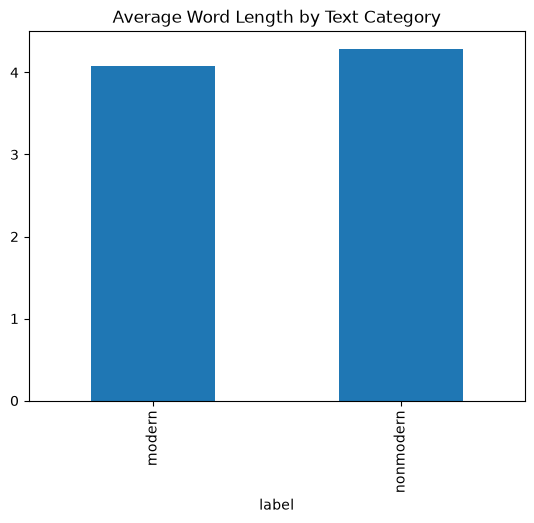

In [120]:
character_df.groupby("label")["average_word_length"].mean().plot(
    kind="bar",
    title="Average Word Length by Text Category"
)

<Axes: title={'center': 'Average Punctuation Ratio by Text Category'}, xlabel='label'>

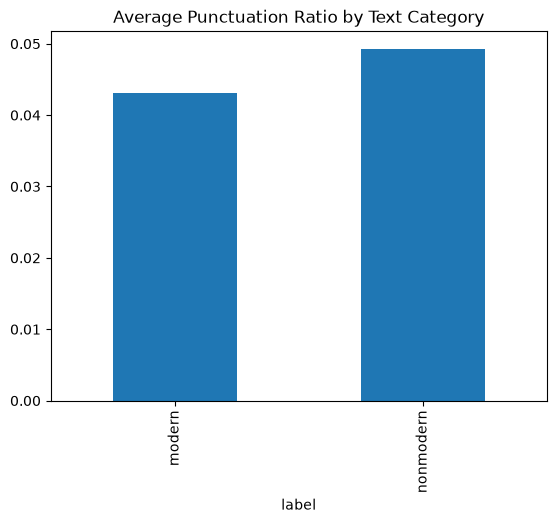

In [121]:
character_df.groupby("label")["punctuation_ratio"].mean().plot(
    kind="bar",
    title="Average Punctuation Ratio by Text Category"
)

In [122]:
punctuation_columns = [
    "comma_ratio",
    "semicolon_ratio",
    "colon_ratio",
    "question_mark_ratio",
    "exclamation_mark_ratio"
]

character_df.groupby("label")[punctuation_columns].mean()

,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio
label,,,,,
modern,0.013622,0.001082,0.000011,0.000473,0.000870
nonmodern,0.014383,0.000617,0.000192,0.000845,0.000534


<Axes: title={'center': 'Punctuation Features by Text Category'}>

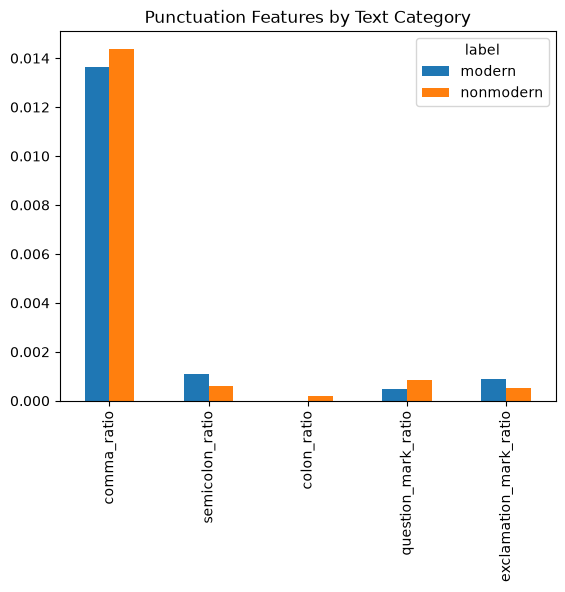

In [123]:
character_df.groupby("label")[punctuation_columns].mean().T.plot(
    kind="bar",
    title="Punctuation Features by Text Category"
)

In [124]:
def get_non_ascii_characters(text):
    return sorted(
        set(
            char for char in text
            if ord(char) > 127
        )
    )

In [125]:
modern_non_ascii = get_non_ascii_characters(modern_text_clean)
nonmodern_non_ascii = get_non_ascii_characters(nonmodern_text_clean)

print("Modern non-ASCII characters:")
print(modern_non_ascii)

print()

print("Nonmodern non-ASCII characters:")
print(nonmodern_non_ascii)

Modern non-ASCII characters:
[]

Nonmodern non-ASCII characters:
[]


In [126]:
for char in modern_non_ascii:
    print(
        repr(char),
        ord(char),
        char.encode("unicode_escape")
    )

In [127]:
def immediate_repetition_features(token_chunk):
    lowercase_tokens = [
        token.lower()
        for token in token_chunk
        if token.isalpha()
    ]

    repeated_pairs = []

    for index in range(len(lowercase_tokens) - 1):
        current_word = lowercase_tokens[index]
        next_word = lowercase_tokens[index + 1]

        if current_word == next_word:
            repeated_pairs.append(current_word)

    return {
        "immediate_repetition_count": len(repeated_pairs),
        "immediate_repetition_types": len(set(repeated_pairs))
    }

In [128]:
immediate_repetition_features(
    ["No", "no", ",", "I", "cannot", "go"]
)

{'immediate_repetition_count': 1, 'immediate_repetition_types': 1}

In [129]:
immediate_rows = []

for chunk in modern_string_chunks:
    features = immediate_repetition_features(chunk)
    features["label"] = "modern"
    immediate_rows.append(features)

for chunk in nonmodern_string_chunks:
    features = immediate_repetition_features(chunk)
    features["label"] = "nonmodern"
    immediate_rows.append(features)

immediate_df = pd.DataFrame(immediate_rows)

immediate_df.head()

,immediate_repetition_count,immediate_repetition_types,label
0,0,0,modern
1,1,1,modern
2,2,2,modern
3,0,0,modern
4,3,2,modern


In [130]:
immediate_df.groupby("label").mean()

,immediate_repetition_count,immediate_repetition_types
label,,
modern,1.313131,1.171717
nonmodern,0.815789,0.815789


### Immediate Repetition

This feature counts adjacent repeated words, such as `no no` or `very very`. It measures one very local form of repetition, but it does not capture words that recur across longer passages.

In [131]:
expanded_style_df = pd.concat(
    [
        character_df.drop(columns=["label"]),
        immediate_df.drop(columns=["label"]),
        character_df["label"]
    ],
    axis=1
)

expanded_style_df.head()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,immediate_repetition_count,immediate_repetition_types,label
0,4.137002,0.034964,0.015193,0.000208,0.0,0.000624,0.000624,0.013774,0.001665,0.0,0,0,modern
1,4.162162,0.037168,0.012874,0.001453,0.0,0.000208,0.000208,0.015393,0.000000,0.0,1,1,modern
2,4.115621,0.050462,0.016534,0.000215,0.0,0.000000,0.000429,0.016652,0.000000,0.0,2,2,modern
3,4.201381,0.028483,0.014241,0.000619,0.0,0.000000,0.000206,0.014563,0.000000,0.0,0,0,modern
4,4.099193,0.031601,0.013098,0.000208,0.0,0.000000,0.000208,0.015031,0.000000,0.0,3,2,modern


In [132]:
expanded_style_df.groupby("label").mean()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,immediate_repetition_count,immediate_repetition_types
label,,,,,,,,,,,,
modern,4.078845,0.043117,0.013622,0.001082,0.000011,0.000473,0.000870,0.019869,0.000017,0.0,1.313131,1.171717
nonmodern,4.289768,0.049313,0.014383,0.000617,0.000192,0.000845,0.000534,0.034880,0.002011,0.0,0.815789,0.815789


In [133]:
stein_text = Path("Stein The Making of Americans AU1600671.txt").read_text(
    encoding="utf-8",
    errors="ignore"
)

print(stein_text[:500])


It is hard living down the tempers we are born with. We all begin well, for in our youth there is nothing we are more intolerant of than our own sins writ large in others and we fight them fiercely in ourselves; but we grow old and we see that these our sins are of all sins the really harmless ones to own, nay that they give a charm to any character, and so our struggle with them dies away.




It has always seemed to me a rare privilege, this, of being an American, a real American, one whose t


In [134]:
stein_text_clean = stein_text

In [135]:
stein_tokens = word_tokenize(stein_text_clean)

stein_tokens = [
    word.lower()
    for word in stein_tokens
]

In [136]:
stein_words = [
    word
    for word in stein_tokens
    if word.isalpha()
]

In [137]:
stein_words = [
    word
    for word in stein_words
    if word not in stop_words
]

In [138]:
print("Number of Stein content words:", len(stein_words))
print(stein_words[:50])

Number of Stein content words: 198372
['hard', 'living', 'tempers', 'born', 'begin', 'well', 'youth', 'nothing', 'intolerant', 'sins', 'writ', 'large', 'others', 'fight', 'fiercely', 'grow', 'old', 'see', 'sins', 'sins', 'really', 'harmless', 'ones', 'nay', 'give', 'charm', 'character', 'struggle', 'dies', 'away', 'always', 'seemed', 'rare', 'privilege', 'american', 'real', 'american', 'one', 'whose', 'tradition', 'taken', 'scarcely', 'sixty', 'years', 'create', 'need', 'realise', 'parents', 'remember', 'grandparents']


In [139]:
stein_fdist = FreqDist(stein_words)
stein_positions = get_word_positions(stein_words)

In [140]:
stein_fdist.most_common(30)

[('one', 18213),
 ('living', 8682),
 ('feeling', 4541),
 ('thing', 4000),
 ('always', 3080),
 ('every', 2393),
 ('kind', 2346),
 ('way', 2225),
 ('hersland', 2213),
 ('many', 2180),
 ('completely', 1980),
 ('men', 1965),
 ('really', 1875),
 ('women', 1863),
 ('certain', 1802),
 ('knowing', 1748),
 ('certainly', 1731),
 ('little', 1646),
 ('something', 1601),
 ('saying', 1545),
 ('inside', 1489),
 ('ones', 1423),
 ('know', 1405),
 ('sometimes', 1375),
 ('beginning', 1350),
 ('would', 1143),
 ('young', 1131),
 ('children', 1121),
 ('loving', 1112),
 ('thinking', 1088)]

In [141]:
import statistics
import pandas as pd

In [142]:
def text_repetition_features(words, positions, min_occurrences=5):
    repeated_word_counts = []
    all_distances = []

    for word, pos in positions.items():
        if len(pos) >= min_occurrences:
            repeated_word_counts.append(len(pos))
            all_distances.extend(repetition_distances(pos))

    total_words = len(words)
    unique_words = len(set(words))

    return {
        "total_words": total_words,
        "unique_words": unique_words,
        "type_token_ratio": unique_words / total_words,
        "repeated_vocabulary_size": len(repeated_word_counts),
        "mean_frequency_repeated_words": statistics.mean(repeated_word_counts),
        "median_repetition_distance": statistics.median(all_distances),
        "mean_repetition_distance": statistics.mean(all_distances)
    }

In [143]:
stein_features = text_repetition_features(
    stein_words,
    stein_positions
)

nonmodern_features = text_repetition_features(
    nonmodern_words,
    nonmodern_positions
)

comparison_df = pd.DataFrame(
    [stein_features, nonmodern_features],
    index=["Stein", "Nonmodern"]
)

comparison_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,198372,5133,0.025876,1869,103.153023,24.0,1119.471743
Nonmodern,14630,4537,0.310116,624,13.519231,305.0,821.724014


In [144]:
comparison_length = min(
    len(stein_words),
    len(nonmodern_words)
)

stein_sample_words = stein_words[:comparison_length]
nonmodern_sample_words = nonmodern_words[:comparison_length]

stein_sample_positions = get_word_positions(stein_sample_words)
nonmodern_sample_positions = get_word_positions(nonmodern_sample_words)

In [145]:
stein_sample_features = text_repetition_features(
    stein_sample_words,
    stein_sample_positions
)

nonmodern_sample_features = text_repetition_features(
    nonmodern_sample_words,
    nonmodern_sample_positions
)

fair_comparison_df = pd.DataFrame(
    [stein_sample_features, nonmodern_sample_features],
    index=["Stein", "Nonmodern"]
)

fair_comparison_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,14630,2176,0.148735,540,22.120370,77.0,433.147216
Nonmodern,14630,4537,0.310116,624,13.519231,305.0,821.724014


In [146]:
common_words = []

for word in set(stein_sample_words) & set(nonmodern_sample_words):
    stein_count = stein_sample_positions[word]
    nonmodern_count = nonmodern_sample_positions[word]

    if len(stein_count) >= 10 and len(nonmodern_count) >= 10:
        common_words.append(
            (
                word,
                len(stein_count),
                len(nonmodern_count)
            )
        )

common_words.sort(
    key=lambda item: item[1] + item[2],
    reverse=True
)

common_words[:20]

[('always', 317, 20),
 ('one', 206, 115),
 ('said', 38, 257),
 ('children', 259, 14),
 ('would', 160, 80),
 ('could', 153, 65),
 ('living', 189, 11),
 ('little', 165, 34),
 ('way', 174, 23),
 ('man', 116, 62),
 ('well', 95, 80),
 ('never', 137, 37),
 ('good', 118, 46),
 ('made', 105, 45),
 ('like', 102, 48),
 ('know', 102, 48),
 ('make', 98, 43),
 ('new', 87, 46),
 ('things', 110, 19),
 ('old', 94, 31)]

In [147]:
def word_repetition_row(word, positions):
    pos = positions[word]
    distances = repetition_distances(pos)

    return {
        "word": word,
        "occurrences": len(pos),
        "frequency_per_1000": len(pos) / comparison_length * 1000,
        "mean_distance": statistics.mean(distances),
        "median_distance": statistics.median(distances)
    }

In [148]:
rows = []

for word, _, _ in common_words[:15]:
    stein_row = word_repetition_row(
        word,
        stein_sample_positions
    )
    stein_row["text"] = "Stein"

    nonmodern_row = word_repetition_row(
        word,
        nonmodern_sample_positions
    )
    nonmodern_row["text"] = "Nonmodern"

    rows.append(stein_row)
    rows.append(nonmodern_row)

common_word_comparison_df = pd.DataFrame(rows)

common_word_comparison_df[
    [
        "text",
        "word",
        "occurrences",
        "frequency_per_1000",
        "mean_distance",
        "median_distance"
    ]
]

,text,word,occurrences,frequency_per_1000,mean_distance,median_distance
0,Stein,always,317,21.667806,46.186709,24.0
1,Nonmodern,always,20,1.367054,738.684211,393.0
2,Stein,one,206,14.080656,71.009756,25.0
3,Nonmodern,one,115,7.860560,124.219298,76.0
4,Stein,said,38,2.597403,346.729730,110.0
5,Nonmodern,said,257,17.566644,56.332031,37.0
6,Stein,children,259,17.703349,55.670543,22.0
7,Nonmodern,children,14,0.956938,999.230769,371.0
8,Stein,would,160,10.936432,89.610063,25.0
9,Nonmodern,would,80,5.468216,173.683544,112.0


## Comparing Equal-Length Samples

I now compare Stein and the selected nonmodernist text using the same number of cleaned content words. This prevents the longer text from producing more repeated words simply because it contains more tokens.

In [149]:
def build_repetition_table(words, positions, min_occurrences=10):
    rows = []

    for word, pos in positions.items():
        occurrences = len(pos)

        if occurrences < min_occurrences:
            continue

        distances = repetition_distances(pos)

        if len(distances) == 0:
            continue

        mean_distance = statistics.mean(distances)
        median_distance = statistics.median(distances)

        if len(distances) > 1:
            standard_deviation = statistics.stdev(distances)
        else:
            standard_deviation = 0

        if mean_distance > 0:
            distance_cv = standard_deviation / mean_distance
        else:
            distance_cv = 0

        short_gap_ratio_50 = sum(
            distance <= 50
            for distance in distances
        ) / len(distances)

        rows.append({
            "word": word,
            "occurrences": occurrences,
            "frequency_per_1000": occurrences / len(words) * 1000,
            "mean_distance": mean_distance,
            "median_distance": median_distance,
            "distance_standard_deviation": standard_deviation,
            "distance_cv": distance_cv,
            "short_gap_ratio_50": short_gap_ratio_50
        })

    return pd.DataFrame(rows)

In [150]:
stein_word_stats = build_repetition_table(
    stein_sample_words,
    stein_sample_positions,
    min_occurrences=10
)

nonmodern_word_stats = build_repetition_table(
    nonmodern_sample_words,
    nonmodern_sample_positions,
    min_occurrences=10
)

In [151]:
stein_word_stats.head(10)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
0,hard,45,3.075871,322.613636,150.0,452.844509,1.403674,0.340909
1,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213
2,born,16,1.093643,943.200000,489.0,1012.819205,1.073812,0.133333
3,begin,14,0.956938,1124.076923,769.0,976.615539,0.868816,0.000000
4,well,95,6.493506,136.563830,47.5,181.112901,1.326214,0.510638
5,nothing,29,1.982228,491.678571,199.0,723.268151,1.471018,0.285714
6,large,11,0.751880,1164.300000,369.0,1427.102040,1.225717,0.200000
7,others,23,1.572112,641.409091,326.5,745.681450,1.162568,0.136364
8,old,94,6.425154,155.526882,37.0,294.553664,1.893908,0.569892
9,see,45,3.075871,308.045455,117.0,478.630457,1.553766,0.409091


In [152]:
nonmodern_word_stats.head(10)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
0,chapter,13,0.888585,1130.916667,1148.0,316.015667,0.279433,0.000000
1,corsica,14,0.956938,921.307692,114.0,2283.014469,2.478015,0.307692
2,brienne,14,0.956938,692.615385,67.0,1786.025921,2.578669,0.384615
3,napoleon,213,14.559125,68.971698,38.0,84.743713,1.228674,0.617925
4,bonaparte,181,12.371839,80.844444,57.0,85.276666,1.054824,0.455556
5,children,14,0.956938,999.230769,371.0,1010.647907,1.011426,0.153846
6,man,62,4.237867,235.983607,128.0,241.608602,1.023836,0.262295
7,became,15,1.025290,817.714286,584.5,790.088352,0.966216,0.214286
8,emperor,74,5.058100,199.315068,60.0,438.685564,2.200965,0.438356
9,french,43,2.939166,346.333333,202.0,436.284348,1.259724,0.095238


In [153]:
stein_word_stats.sort_values(
    by="frequency_per_1000",
    ascending=False
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
14,always,317,21.667806,46.186709,24.0,52.234210,1.130936,0.702532
43,children,259,17.703349,55.670543,22.0,171.705396,3.084313,0.767442
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
16,one,206,14.080656,71.009756,25.0,120.230946,1.693161,0.653659
1,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213
72,way,174,11.893370,82.046243,52.0,96.937694,1.181501,0.479769
30,little,165,11.278195,87.128049,30.5,148.344573,1.702604,0.628049
58,would,160,10.936432,89.610063,25.0,153.687292,1.715067,0.635220
71,could,153,10.457963,89.736842,44.0,125.203767,1.395233,0.526316
38,inside,144,9.842789,101.412587,29.0,229.329867,2.261355,0.699301


In [154]:
nonmodern_word_stats.sort_values(
    by="frequency_per_1000",
    ascending=False
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
46,said,257,17.566644,56.332031,37.0,53.032982,0.941436,0.589844
3,napoleon,213,14.559125,68.971698,38.0,84.743713,1.228674,0.617925
4,bonaparte,181,12.371839,80.844444,57.0,85.276666,1.054824,0.455556
86,one,115,7.860560,124.219298,76.0,137.672354,1.108301,0.412281
22,would,80,5.468216,173.683544,112.0,175.453737,1.010192,0.265823
80,well,80,5.468216,169.417722,139.0,141.561675,0.835578,0.189873
8,emperor,74,5.058100,199.315068,60.0,438.685564,2.200965,0.438356
169,fouche,74,5.058100,181.205479,31.0,866.739804,4.783188,0.671233
156,paris,73,4.989747,183.597222,138.0,202.214895,1.101405,0.305556
16,joseph,69,4.716336,214.294118,37.0,380.497869,1.775587,0.544118


The tables include words that occur at least ten times in each equal-length sample. Frequency is reported per 1,000 content words. I also report median repetition distance because a small number of very large gaps can strongly affect the mean.

In [155]:
stein_word_stats.sort_values(
    by="median_distance",
    ascending=True
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
272,tired,16,1.093643,9.466667,6.0,12.094076,1.277543,0.933333
282,shilling,19,1.298701,94.333333,6.5,276.011296,2.925915,0.777778
51,us,91,6.220096,160.444444,7.0,491.388153,3.062669,0.788889
195,washing,21,1.435407,68.600000,9.0,235.624009,3.434752,0.950000
250,papa,19,1.298701,350.388889,10.5,975.896941,2.785182,0.611111
261,dying,13,0.888585,561.666667,11.0,1773.442125,3.157464,0.750000
268,religion,70,4.784689,87.985507,13.0,378.801768,4.305275,0.797101
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
242,singularity,11,0.751880,634.200000,16.0,1904.353947,3.002766,0.700000
171,george,20,1.367054,297.052632,19.0,581.005878,1.955902,0.578947


In [156]:
stein_word_stats.sort_values(
    by="median_distance",
    ascending=True
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
272,tired,16,1.093643,9.466667,6.0,12.094076,1.277543,0.933333
282,shilling,19,1.298701,94.333333,6.5,276.011296,2.925915,0.777778
51,us,91,6.220096,160.444444,7.0,491.388153,3.062669,0.788889
195,washing,21,1.435407,68.600000,9.0,235.624009,3.434752,0.950000
250,papa,19,1.298701,350.388889,10.5,975.896941,2.785182,0.611111
261,dying,13,0.888585,561.666667,11.0,1773.442125,3.157464,0.750000
268,religion,70,4.784689,87.985507,13.0,378.801768,4.305275,0.797101
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
242,singularity,11,0.751880,634.200000,16.0,1904.353947,3.002766,0.700000
171,george,20,1.367054,297.052632,19.0,581.005878,1.955902,0.578947


In [157]:
def summarize_repetition_table(word_stats):
    return {
        "eligible_word_types": len(word_stats),

        "median_frequency_per_1000": word_stats[
            "frequency_per_1000"
        ].median(),

        "median_of_mean_distances": word_stats[
            "mean_distance"
        ].median(),

        "median_of_median_distances": word_stats[
            "median_distance"
        ].median(),

        "median_short_gap_ratio_50": word_stats[
            "short_gap_ratio_50"
        ].median(),

        "median_distance_cv": word_stats[
            "distance_cv"
        ].median()
    }

In [158]:
stein_repetition_summary = summarize_repetition_table(
    stein_word_stats
)

nonmodern_repetition_summary = summarize_repetition_table(
    nonmodern_word_stats
)

In [159]:
text_level_comparison_df = pd.DataFrame(
    [
        stein_repetition_summary,
        nonmodern_repetition_summary
    ],
    index=[
        "Stein",
        "Nonmodern"
    ]
)

text_level_comparison_df

,eligible_word_types,median_frequency_per_1000,median_of_mean_distances,median_of_median_distances,median_short_gap_ratio_50,median_distance_cv
Stein,283,1.367054,496.857143,150.5,0.342105,1.491299
Nonmodern,239,1.093643,737.705882,438.5,0.153846,1.059996


### Text-Level Feature Definitions

- **eligible_word_types**: Number of word types occurring at least ten times in the sample.
- **median_frequency_per_1000**: Median normalized frequency of the eligible words.
- **median_of_mean_distances**: Median of the mean repetition distances for the eligible words.
- **median_of_median_distances**: Median of the median repetition distances for the eligible words.
- **median_short_gap_ratio_50**: Median proportion of repetition gaps that are 50 content words or fewer.
- **median_distance_cv**: Median coefficient of variation of the repetition distances.

In [160]:
shared_word_stats = pd.merge(
    stein_word_stats,
    nonmodern_word_stats,
    on="word",
    suffixes=("_stein", "_nonmodern")
)

print(
    "Number of shared words appearing at least 10 times in both texts:",
    len(shared_word_stats)
)

shared_word_stats.head()

Number of shared words appearing at least 10 times in both texts: 110


,word,occurrences_stein,frequency_per_1000_stein,mean_distance_stein,median_distance_stein,distance_standard_deviation_stein,distance_cv_stein,short_gap_ratio_50_stein,occurrences_nonmodern,frequency_per_1000_nonmodern,mean_distance_nonmodern,median_distance_nonmodern,distance_standard_deviation_nonmodern,distance_cv_nonmodern,short_gap_ratio_50_nonmodern
0,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213,11,0.751880,1086.300000,955.5,909.237538,0.837004,0.100000
1,well,95,6.493506,136.563830,47.5,181.112901,1.326214,0.510638,80,5.468216,169.417722,139.0,141.561675,0.835578,0.189873
2,nothing,29,1.982228,491.678571,199.0,723.268151,1.471018,0.285714,19,1.298701,699.944444,526.5,758.853739,1.084163,0.055556
3,old,94,6.425154,155.526882,37.0,294.553664,1.893908,0.569892,31,2.118934,476.733333,323.0,602.591125,1.264000,0.266667
4,see,45,3.075871,308.045455,117.0,478.630457,1.553766,0.409091,40,2.734108,354.333333,246.0,383.804112,1.083172,0.256410


In [161]:
shared_word_stats[
    "frequency_difference"
] = (
    shared_word_stats["frequency_per_1000_stein"]
    - shared_word_stats["frequency_per_1000_nonmodern"]
)

shared_word_stats[
    "median_distance_difference"
] = (
    shared_word_stats["median_distance_nonmodern"]
    - shared_word_stats["median_distance_stein"]
)

shared_word_stats[
    "short_gap_ratio_difference"
] = (
    shared_word_stats["short_gap_ratio_50_stein"]
    - shared_word_stats["short_gap_ratio_50_nonmodern"]
)

In [162]:
shared_word_stats[
    [
        "word",
        "occurrences_stein",
        "occurrences_nonmodern",
        "frequency_per_1000_stein",
        "frequency_per_1000_nonmodern",
        "median_distance_stein",
        "median_distance_nonmodern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_nonmodern",
        "median_distance_difference"
    ]
].sort_values(
    by="median_distance_difference",
    ascending=False
).head(20)

,word,occurrences_stein,occurrences_nonmodern,frequency_per_1000_stein,frequency_per_1000_nonmodern,median_distance_stein,median_distance_nonmodern,short_gap_ratio_50_stein,short_gap_ratio_50_nonmodern,median_distance_difference
98,whole,11,11,0.751880,0.751880,168.0,1582.5,0.200000,0.000000,1414.5
33,woman,59,14,4.032809,0.956938,115.5,1053.0,0.379310,0.076923,937.5
0,living,189,11,12.918660,0.751880,25.0,955.5,0.670213,0.100000,930.5
90,business,20,10,1.367054,0.683527,350.0,1227.0,0.263158,0.111111,877.0
24,young,94,11,6.425154,0.751880,54.0,923.0,0.483871,0.000000,869.0
97,three,32,17,2.187286,1.161996,69.0,767.0,0.387097,0.000000,698.0
8,real,30,11,2.050581,0.751880,219.0,866.0,0.172414,0.200000,647.0
109,keep,26,15,1.777170,1.025290,74.0,693.5,0.440000,0.142857,619.5
87,best,12,11,0.820232,0.751880,320.0,849.0,0.090909,0.000000,529.0
91,better,18,14,1.230349,0.956938,155.0,663.0,0.294118,0.000000,508.0


In [163]:
shared_word_stats[
    [
        "word",
        "occurrences_stein",
        "occurrences_nonmodern",
        "frequency_per_1000_stein",
        "frequency_per_1000_nonmodern",
        "median_distance_stein",
        "median_distance_nonmodern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_nonmodern",
        "median_distance_difference"
    ]
].sort_values(
    by="median_distance_difference",
    ascending=True
).head(20)

,word,occurrences_stein,occurrences_nonmodern,frequency_per_1000_stein,frequency_per_1000_nonmodern,median_distance_stein,median_distance_nonmodern,short_gap_ratio_50_stein,short_gap_ratio_50_nonmodern,median_distance_difference
99,two,11,35,0.751880,2.392344,1021.5,287.0,0.000000,0.117647,-734.5
106,course,10,12,0.683527,0.820232,1412.0,730.0,0.222222,0.000000,-682.0
56,friends,11,12,0.751880,0.820232,878.5,211.0,0.000000,0.272727,-667.5
95,city,10,14,0.683527,0.956938,712.0,302.0,0.333333,0.153846,-410.0
100,take,14,30,0.956938,2.050581,555.0,241.0,0.000000,0.068966,-314.0
35,rest,10,15,0.683527,1.025290,718.0,474.0,0.333333,0.142857,-244.0
5,give,23,30,1.572112,2.050581,549.0,359.0,0.090909,0.103448,-190.0
104,began,15,17,1.025290,1.161996,556.5,367.0,0.142857,0.187500,-189.5
62,without,16,20,1.093643,1.367054,551.0,366.0,0.200000,0.157895,-185.0
71,boy,10,12,0.683527,0.820232,491.0,329.0,0.333333,0.181818,-162.0


In [164]:
shared_words_summary_df = pd.DataFrame({
    "Stein": {
        "shared_word_count": len(shared_word_stats),

        "median_frequency_per_1000": shared_word_stats[
            "frequency_per_1000_stein"
        ].median(),

        "median_repetition_distance": shared_word_stats[
            "median_distance_stein"
        ].median(),

        "median_short_gap_ratio_50": shared_word_stats[
            "short_gap_ratio_50_stein"
        ].median(),

        "median_distance_cv": shared_word_stats[
            "distance_cv_stein"
        ].median()
    },

    "Nonmodern": {
        "shared_word_count": len(shared_word_stats),

        "median_frequency_per_1000": shared_word_stats[
            "frequency_per_1000_nonmodern"
        ].median(),

        "median_repetition_distance": shared_word_stats[
            "median_distance_nonmodern"
        ].median(),

        "median_short_gap_ratio_50": shared_word_stats[
            "short_gap_ratio_50_nonmodern"
        ].median(),

        "median_distance_cv": shared_word_stats[
            "distance_cv_nonmodern"
        ].median()
    }
}).T

shared_words_summary_df

,shared_word_count,median_frequency_per_1000,median_repetition_distance,median_short_gap_ratio_50,median_distance_cv
Stein,110.0,2.016405,165.0,0.340580,1.400645
Nonmodern,110.0,1.435407,366.5,0.142857,1.040991


In [165]:
stein_shorter_count = (
    shared_word_stats["median_distance_stein"]
    <
    shared_word_stats["median_distance_nonmodern"]
).sum()

nonmodern_shorter_count = (
    shared_word_stats["median_distance_nonmodern"]
    <
    shared_word_stats["median_distance_stein"]
).sum()

equal_distance_count = (
    shared_word_stats["median_distance_stein"]
    ==
    shared_word_stats["median_distance_nonmodern"]
).sum()

print(
    "Words with shorter median repetition distance in Stein:",
    stein_shorter_count
)

print(
    "Words with shorter median repetition distance in Nonmodern:",
    nonmodern_shorter_count
)

print(
    "Words with equal median repetition distance:",
    equal_distance_count
)

Words with shorter median repetition distance in Stein: 88
Words with shorter median repetition distance in Nonmodern: 22
Words with equal median repetition distance: 0


In [166]:
stein_shorter_percentage = (
    stein_shorter_count
    / len(shared_word_stats)
    * 100
)

nonmodern_shorter_percentage = (
    nonmodern_shorter_count
    / len(shared_word_stats)
    * 100
)

print(
    "Percentage of shared words repeating sooner in Stein:",
    round(stein_shorter_percentage, 2),
    "%"
)

print(
    "Percentage of shared words repeating sooner in Nonmodern:",
    round(nonmodern_shorter_percentage, 2),
    "%"
)

Percentage of shared words repeating sooner in Stein: 80.0 %
Percentage of shared words repeating sooner in Nonmodern: 20.0 %


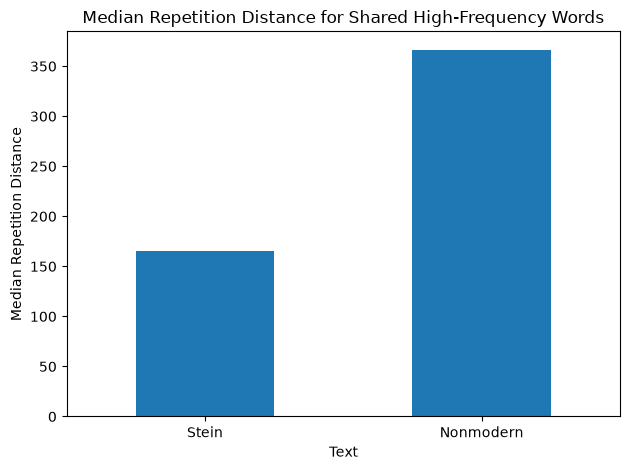

In [167]:
distance_plot_data = shared_words_summary_df[
    ["median_repetition_distance"]
]

distance_plot_data.plot(
    kind="bar",
    legend=False
)

plt.title(
    "Median Repetition Distance for Shared High-Frequency Words"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

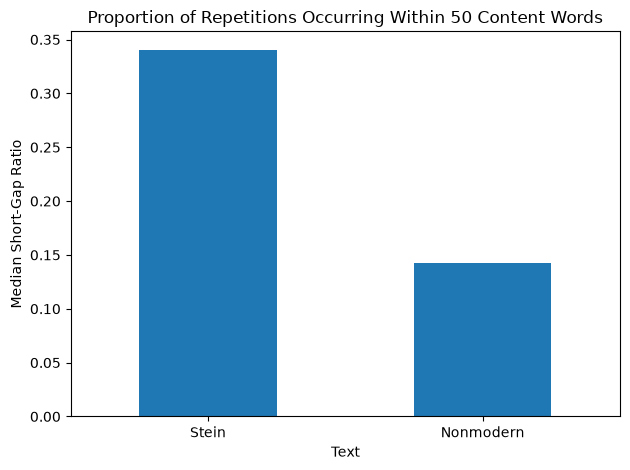

In [168]:
short_gap_plot_data = shared_words_summary_df[
    ["median_short_gap_ratio_50"]
]

short_gap_plot_data.plot(
    kind="bar",
    legend=False
)

plt.title(
    "Proportion of Repetitions Occurring Within 50 Content Words"
)

plt.xlabel("Text")
plt.ylabel("Median Short-Gap Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

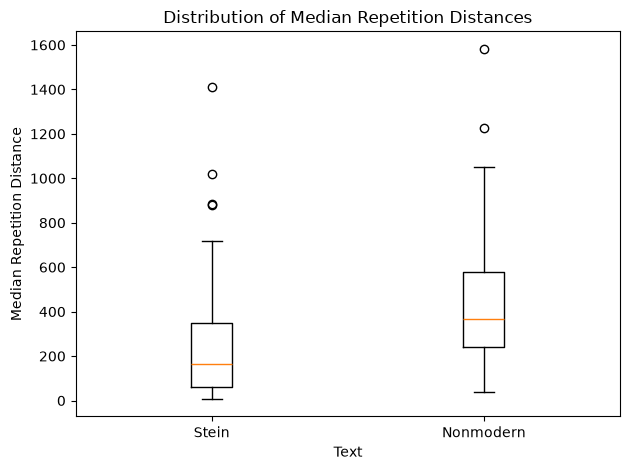

In [169]:
plt.boxplot(
    [
        shared_word_stats["median_distance_stein"],
        shared_word_stats["median_distance_nonmodern"]
    ],
    tick_labels=[
        "Stein",
        "Nonmodern"
    ]
)

plt.title(
    "Distribution of Median Repetition Distances"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.tight_layout()
plt.show()

In [170]:
stein_shared_median_distance = shared_words_summary_df.loc[
    "Stein",
    "median_repetition_distance"
]

nonmodern_shared_median_distance = shared_words_summary_df.loc[
    "Nonmodern",
    "median_repetition_distance"
]

stein_shared_short_gap = shared_words_summary_df.loc[
    "Stein",
    "median_short_gap_ratio_50"
]

nonmodern_shared_short_gap = shared_words_summary_df.loc[
    "Nonmodern",
    "median_short_gap_ratio_50"
]

print("RESULT SUMMARY")
print()

print(
    "The analysis compared",
    len(shared_word_stats),
    "word types that appeared at least ten times in both equal-length text samples."
)

print()

print(
    "The median repetition distance was",
    round(stein_shared_median_distance, 2),
    "for Stein and",
    round(nonmodern_shared_median_distance, 2),
    "for the nonmodern text."
)

print()

print(
    "The median short-gap ratio was",
    round(stein_shared_short_gap, 3),
    "for Stein and",
    round(nonmodern_shared_short_gap, 3),
    "for the nonmodern text."
)

print()

print(
    round(stein_shorter_percentage, 2),
    "% of the shared high-frequency words repeated sooner in Stein."
)

RESULT SUMMARY

The analysis compared 110 word types that appeared at least ten times in both equal-length text samples.

The median repetition distance was 165.0 for Stein and 366.5 for the nonmodern text.

The median short-gap ratio was 0.341 for Stein and 0.143 for the nonmodern text.

80.0 % of the shared high-frequency words repeated sooner in Stein.


## Preliminary Interpretation

I compared equal-length samples from *The Making of Americans* and the selected nonmodernist text. The shared-vocabulary analysis includes only words that occur at least ten times in both samples.

Several shared words, including *always*, *children*, and *living*, are more frequent in Stein, have shorter repetition intervals, or show both patterns. This pattern is not true for every word. For example, *said* is more frequent and repeats at shorter intervals in the nonmodernist text.

This case study suggests that repetition differs across the two works, but it cannot establish a general difference between modernist and nonmodernist writing. The result may also reflect author, subject matter, genre, or narrative structure.

# Stein and Another Modernist Text

The first comparison cannot show whether Stein differs specifically from nonmodernist writing or from other modernist writing more generally. I therefore repeat the analysis using Stein and one text from the modernist corpus.

I use the same preprocessing, equal-length sampling, shared-vocabulary threshold, and repetition measurements as in the first comparison.

In [171]:
print("Stein content words:", len(stein_words))
print("Selected modernist text content words:", len(modern_words))

Stein content words: 198372
Selected modernist text content words: 37783


In [172]:
stein_modern_comparison_length = min(len(stein_words), len(modern_words))

stein_modern_sample_words = stein_words[:stein_modern_comparison_length]
ordinary_modern_sample_words = modern_words[:stein_modern_comparison_length]

print("Comparison length:", stein_modern_comparison_length)
print("Stein sample length:", len(stein_modern_sample_words))
print("Selected modernist sample length:", len(ordinary_modern_sample_words))

Comparison length: 37783
Stein sample length: 37783
Selected modernist sample length: 37783


## Equal-Length Sampling

The Stein text is longer than the selected modernist text, so I use the same number of cleaned content words from each. This controls sample length, although the result still depends on which section of each work is selected.

In [173]:
stein_modern_sample_positions = get_word_positions(stein_modern_sample_words)
ordinary_modern_sample_positions = get_word_positions(ordinary_modern_sample_words)

In [174]:
print(
    "Number of word types in Stein:",
    len(stein_modern_sample_positions)
)

print(
    "Number of word types in selected modernist text:",
    len(ordinary_modern_sample_positions)
)

Number of word types in Stein: 2642
Number of word types in selected modernist text: 5983


In [175]:
stein_always_positions = stein_modern_sample_positions.get("always", [])[:20]
modern_always_positions = ordinary_modern_sample_positions.get("always", [])[:20]

print("Positions of 'always' in Stein:")
print(stein_always_positions)

print()

print("Positions of 'always' in the selected modernist text:")
print(modern_always_positions)

Positions of 'always' in Stein:
[30, 111, 158, 164, 176, 288, 293, 300, 332, 343, 462, 473, 533, 551, 600, 617, 677, 680, 686, 689]

Positions of 'always' in the selected modernist text:
[1170, 2050, 2217, 2261, 3393, 3856, 3864, 6361, 6441, 6970, 7843, 8044, 8274, 9403, 9823, 9856, 9876, 10079, 11416, 11451]


In [176]:
print("Positions of 'always' in Stein:")

print(
    stein_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

print()

print("Positions of 'always' in selected modernist text:")

print(
    ordinary_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

Positions of 'always' in Stein:
[30, 111, 158, 164, 176, 288, 293, 300, 332, 343, 462, 473, 533, 551, 600, 617, 677, 680, 686, 689]

Positions of 'always' in selected modernist text:
[1170, 2050, 2217, 2261, 3393, 3856, 3864, 6361, 6441, 6970, 7843, 8044, 8274, 9403, 9823, 9856, 9876, 10079, 11416, 11451]


In [177]:
stein_modern_sample_fdist = FreqDist(
    stein_modern_sample_words
)

ordinary_modern_sample_fdist = FreqDist(
    ordinary_modern_sample_words
)

## Word Positions and Frequencies

For each sample, I store the token positions of every content word. Consecutive positions are used to calculate repetition distances.

I also create frequency distributions to identify words that occur often in both Stein and the selected modernist text.

In [178]:
stein_ordinary_modern_features = text_repetition_features(
    stein_modern_sample_words,
    stein_modern_sample_positions
)

ordinary_modern_features = text_repetition_features(
    ordinary_modern_sample_words,
    ordinary_modern_sample_positions
)

In [179]:
stein_vs_ordinary_modern_df = pd.DataFrame(
    [
        stein_ordinary_modern_features,
        ordinary_modern_features
    ],
    index=[
        "Stein",
        "Selected Modernist"
    ]
)

stein_vs_ordinary_modern_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,37783,2642,0.069926,828,41.992754,50.0,577.322403
Selected Modernist,37783,5983,0.158352,1476,20.544715,396.0,1419.290037


## Overall Repetition Features

The table compares lexical diversity, repeated vocabulary, and the spacing between repetitions in the two equal-length samples.

Type-token ratio measures the proportion of unique words. Median repetition distance measures the typical number of content words between consecutive occurrences, so a lower value indicates that repeated words return more quickly.

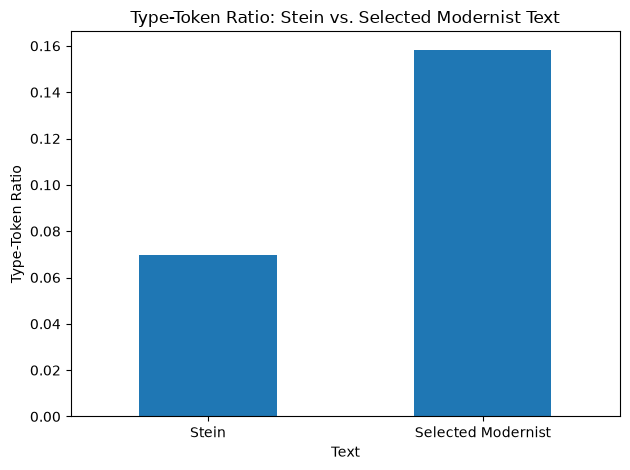

In [180]:
stein_vs_ordinary_modern_df[
    "type_token_ratio"
].plot(
    kind="bar",
    title="Type-Token Ratio: Stein vs. Selected Modernist Text"
)

plt.xlabel("Text")
plt.ylabel("Type-Token Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

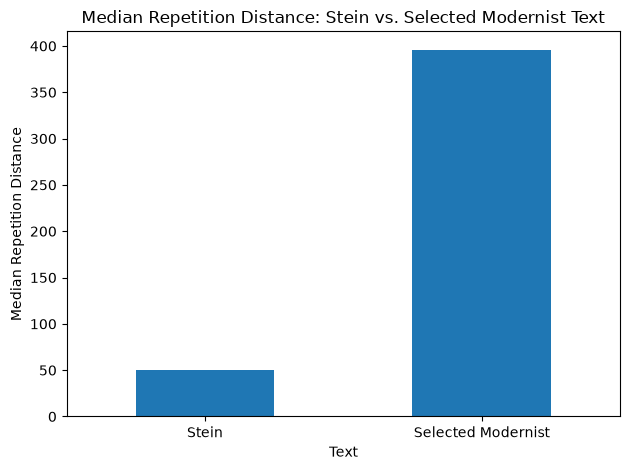

In [181]:
stein_vs_ordinary_modern_df[
    "median_repetition_distance"
].plot(
    kind="bar",
    title="Median Repetition Distance: Stein vs. Selected Modernist Text"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Shared High-Frequency Vocabulary

Character names and topic-specific words can dominate a comparison between two books. I therefore keep words that occur at least ten times in both samples.

This makes the comparison less dependent on vocabulary that appears in only one work, although it does not remove all differences in subject matter.

In [182]:
minimum_shared_frequency = 10

stein_ordinary_shared_words = sorted(
    [
        word
        for word in stein_modern_sample_fdist
        if (
            stein_modern_sample_fdist[word]
            >= minimum_shared_frequency
            and
            ordinary_modern_sample_fdist[word]
            >= minimum_shared_frequency
        )
    ]
)

print(
    "Number of shared high-frequency words:",
    len(stein_ordinary_shared_words)
)

print()

print("First 50 shared words:")

print(
    stein_ordinary_shared_words[:50]
)

Number of shared high-frequency words: 251

First 50 shared words:
['afraid', 'age', 'almost', 'alone', 'already', 'always', 'among', 'another', 'asked', 'away', 'back', 'bear', 'beauty', 'began', 'behind', 'believe', 'best', 'better', 'big', 'body', 'born', 'boy', 'break', 'bright', 'broke', 'brought', 'came', 'certain', 'change', 'child', 'children', 'choose', 'clear', 'close', 'come', 'comes', 'coming', 'common', 'could', 'country', 'cut', 'daughter', 'day', 'days', 'dead', 'died', 'dogs', 'done', 'early', 'either']


In [183]:
def shared_word_repetition_features(
    word,
    words,
    positions,
    short_gap_threshold=50
):
    word_positions = positions[word]

    distances = repetition_distances(
        word_positions
    )

    frequency = len(word_positions)

    frequency_per_1000 = (
        frequency / len(words)
    ) * 1000

    if len(distances) == 0:
        median_distance = np.nan
        mean_distance = np.nan
        distance_std = np.nan
        short_gap_ratio = np.nan
        distance_cv = np.nan

    else:
        median_distance = statistics.median(
            distances
        )

        mean_distance = statistics.mean(
            distances
        )

        if len(distances) >= 2:
            distance_std = statistics.stdev(
                distances
            )
        else:
            distance_std = 0

        short_gap_count = sum(
            distance <= short_gap_threshold
            for distance in distances
        )

        short_gap_ratio = (
            short_gap_count / len(distances)
        )

        if mean_distance != 0:
            distance_cv = (
                distance_std / mean_distance
            )
        else:
            distance_cv = np.nan

    return {
        "frequency": frequency,
        "frequency_per_1000": frequency_per_1000,
        "median_distance": median_distance,
        "mean_distance": mean_distance,
        "distance_std": distance_std,
        "short_gap_ratio_50": short_gap_ratio,
        "distance_cv": distance_cv
    }

In [184]:
test_word = stein_ordinary_shared_words[0]

print("Test word:", test_word)

print()

print("Stein:")
print(
    shared_word_repetition_features(
        test_word,
        stein_modern_sample_words,
        stein_modern_sample_positions
    )
)

print()

print("Ordinary modernist:")
print(
    shared_word_repetition_features(
        test_word,
        ordinary_modern_sample_words,
        ordinary_modern_sample_positions
    )
)

Test word: afraid

Stein:
{'frequency': 26, 'frequency_per_1000': 0.6881401688590107, 'median_distance': 12, 'mean_distance': 1006.72, 'distance_std': 1969.723870664786, 'short_gap_ratio_50': 0.56, 'distance_cv': 1.9565756820812004}

Ordinary modernist:
{'frequency': 19, 'frequency_per_1000': 0.5028716618585077, 'median_distance': 1052.5, 'mean_distance': 1525.611111111111, 'distance_std': 1543.109585483305, 'short_gap_ratio_50': 0.1111111111111111, 'distance_cv': 1.011469813142256}


In [185]:
stein_ordinary_shared_rows = []

for word in stein_ordinary_shared_words:
    stein_word_features = (
        shared_word_repetition_features(
            word,
            stein_modern_sample_words,
            stein_modern_sample_positions
        )
    )

    ordinary_modern_word_features = (
        shared_word_repetition_features(
            word,
            ordinary_modern_sample_words,
            ordinary_modern_sample_positions
        )
    )

    row = {
        "word": word,

        "frequency_stein":
            stein_word_features["frequency"],

        "frequency_ordinary_modern":
            ordinary_modern_word_features[
                "frequency"
            ],

        "frequency_per_1000_stein":
            stein_word_features[
                "frequency_per_1000"
            ],

        "frequency_per_1000_ordinary_modern":
            ordinary_modern_word_features[
                "frequency_per_1000"
            ],

        "median_distance_stein":
            stein_word_features[
                "median_distance"
            ],

        "median_distance_ordinary_modern":
            ordinary_modern_word_features[
                "median_distance"
            ],

        "short_gap_ratio_50_stein":
            stein_word_features[
                "short_gap_ratio_50"
            ],

        "short_gap_ratio_50_ordinary_modern":
            ordinary_modern_word_features[
                "short_gap_ratio_50"
            ],

        "distance_cv_stein":
            stein_word_features[
                "distance_cv"
            ],

        "distance_cv_ordinary_modern":
            ordinary_modern_word_features[
                "distance_cv"
            ]
    }

    stein_ordinary_shared_rows.append(row)

In [186]:
stein_ordinary_shared_df = pd.DataFrame(
    stein_ordinary_shared_rows
)

stein_ordinary_shared_df.head(20)

,word,frequency_stein,frequency_ordinary_modern,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern,distance_cv_stein,distance_cv_ordinary_modern
0,afraid,26,19,0.688140,0.502872,12.0,1052.5,0.560000,0.111111,1.956576,1.011470
1,age,15,15,0.397004,0.397004,1333.0,503.0,0.285714,0.000000,1.053586,1.801001
2,almost,99,64,2.620226,1.693883,133.5,308.0,0.367347,0.079365,1.366741,1.030272
3,alone,17,44,0.449938,1.164545,569.5,687.0,0.375000,0.116279,1.309855,0.868037
4,already,21,10,0.555806,0.264669,794.5,2666.0,0.100000,0.111111,1.228475,0.827585
5,always,791,49,20.935341,1.296880,22.0,441.5,0.710127,0.125000,1.417664,0.990292
6,among,32,62,0.846942,1.640950,425.0,358.0,0.290323,0.147541,1.356683,1.034253
7,another,48,42,1.270413,1.111611,175.0,637.0,0.276596,0.121951,1.800072,0.968239
8,asked,13,24,0.344070,0.635206,751.0,982.0,0.250000,0.043478,1.261329,1.183610
9,away,147,82,3.890639,2.170288,52.0,239.0,0.479452,0.197531,2.040301,1.108272


In [187]:
stein_ordinary_shared_df[
    "frequency_difference"
] = (
    stein_ordinary_shared_df[
        "frequency_per_1000_stein"
    ]
    -
    stein_ordinary_shared_df[
        "frequency_per_1000_ordinary_modern"
    ]
)

stein_ordinary_shared_df[
    "median_distance_difference"
] = (
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
    -
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
)

stein_ordinary_shared_df[
    "short_gap_ratio_difference"
] = (
    stein_ordinary_shared_df[
        "short_gap_ratio_50_stein"
    ]
    -
    stein_ordinary_shared_df[
        "short_gap_ratio_50_ordinary_modern"
    ]
)

stein_ordinary_shared_df.head()

,word,frequency_stein,frequency_ordinary_modern,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern,distance_cv_stein,distance_cv_ordinary_modern,frequency_difference,median_distance_difference,short_gap_ratio_difference
0,afraid,26,19,0.688140,0.502872,12.0,1052.5,0.560000,0.111111,1.956576,1.011470,0.185269,1040.5,0.448889
1,age,15,15,0.397004,0.397004,1333.0,503.0,0.285714,0.000000,1.053586,1.801001,0.000000,-830.0,0.285714
2,almost,99,64,2.620226,1.693883,133.5,308.0,0.367347,0.079365,1.366741,1.030272,0.926343,174.5,0.287982
3,alone,17,44,0.449938,1.164545,569.5,687.0,0.375000,0.116279,1.309855,0.868037,-0.714607,117.5,0.258721
4,already,21,10,0.555806,0.264669,794.5,2666.0,0.100000,0.111111,1.228475,0.827585,0.291136,1871.5,-0.011111


In [188]:
stein_ordinary_shared_df.sort_values(
    by="median_distance_difference",
    ascending=False
)[
    [
        "word",
        "frequency_per_1000_stein",
        "frequency_per_1000_ordinary_modern",
        "median_distance_stein",
        "median_distance_ordinary_modern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_ordinary_modern"
    ]
].head(20)

,word,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern
212,thin,0.264669,0.264669,118.0,3385.0,0.444444,0.000000
125,lose,0.635206,0.264669,273.0,3284.0,0.304348,0.111111
174,remember,0.476405,0.264669,166.0,3130.0,0.470588,0.000000
87,half,1.032210,0.317603,3.5,2774.0,0.842105,0.181818
196,stayed,0.264669,0.291136,54.0,2680.5,0.444444,0.000000
231,weakness,1.243946,0.370537,58.5,2597.0,0.478261,0.076923
119,living,26.784533,0.344070,14.0,2268.0,0.818002,0.000000
105,large,0.423471,0.344070,633.0,2862.5,0.200000,0.000000
153,nothing,2.620226,0.397004,58.5,2200.5,0.479592,0.142857
40,cut,0.608739,0.317603,377.5,2497.0,0.318182,0.000000


In [189]:
stein_ordinary_shared_df.sort_values(
    by="median_distance_difference",
    ascending=True
)[
    [
        "word",
        "frequency_per_1000_stein",
        "frequency_per_1000_ordinary_modern",
        "median_distance_stein",
        "median_distance_ordinary_modern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_ordinary_modern"
    ]
].head(20)

,word,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern
44,dead,0.291136,0.873409,1896.5,271.0,0.300000,0.218750
169,pretty,0.264669,0.529339,1820.0,438.0,0.000000,0.052632
198,strange,0.344070,2.170288,1651.0,287.0,0.333333,0.234568
96,joy,0.317603,1.005743,1491.0,184.0,0.090909,0.162162
172,quite,0.264669,0.397004,2161.0,865.0,0.111111,0.142857
205,sweet,0.317603,0.767541,1549.0,331.0,0.181818,0.142857
25,brought,0.397004,0.767541,1816.5,599.0,0.142857,0.071429
50,else,0.423471,0.661673,1921.0,756.0,0.133333,0.125000
103,known,0.291136,1.217479,1548.0,410.0,0.000000,0.088889
141,might,0.582272,3.573035,1291.0,178.0,0.142857,0.320896


In [190]:
stein_ordinary_shared_summary_df = pd.DataFrame(
    {
        "shared_word_count": [
            len(stein_ordinary_shared_df),
            len(stein_ordinary_shared_df)
        ],

        "median_frequency_per_1000": [
            stein_ordinary_shared_df[
                "frequency_per_1000_stein"
            ].median(),

            stein_ordinary_shared_df[
                "frequency_per_1000_ordinary_modern"
            ].median()
        ],

        "median_repetition_distance": [
            stein_ordinary_shared_df[
                "median_distance_stein"
            ].median(),

            stein_ordinary_shared_df[
                "median_distance_ordinary_modern"
            ].median()
        ],

        "median_short_gap_ratio_50": [
            stein_ordinary_shared_df[
                "short_gap_ratio_50_stein"
            ].median(),

            stein_ordinary_shared_df[
                "short_gap_ratio_50_ordinary_modern"
            ].median()
        ],

        "median_distance_cv": [
            stein_ordinary_shared_df[
                "distance_cv_stein"
            ].median(),

            stein_ordinary_shared_df[
                "distance_cv_ordinary_modern"
            ].median()
        ]
    },
    index=[
        "Stein",
        "Selected Modernist"
    ]
)

stein_ordinary_shared_summary_df

,shared_word_count,median_frequency_per_1000,median_repetition_distance,median_short_gap_ratio_50,median_distance_cv
Stein,251,0.952809,183.0,0.333333,1.739687
Selected Modernist,251,0.846942,592.0,0.117647,1.151580


In [191]:
stein_shorter_word_count = (
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
    <
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
).sum()

ordinary_modern_shorter_word_count = (
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
    <
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
).sum()

equal_distance_word_count = (
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
    ==
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
).sum()

stein_shorter_percentage = (
    stein_shorter_word_count
    /
    len(stein_ordinary_shared_df)
) * 100

print(
    "Words repeating sooner in Stein:",
    stein_shorter_word_count
)

print(
    "Words repeating sooner in Selected Modernist Text:",
    ordinary_modern_shorter_word_count
)

print(
    "Words with equal median repetition distance:",
    equal_distance_word_count
)

print(
    "Percentage repeating sooner in Stein:",
    round(stein_shorter_percentage, 2),
    "%"
)

Words repeating sooner in Stein: 198
Words repeating sooner in Selected Modernist Text: 53
Words with equal median repetition distance: 0
Percentage repeating sooner in Stein: 78.88 %


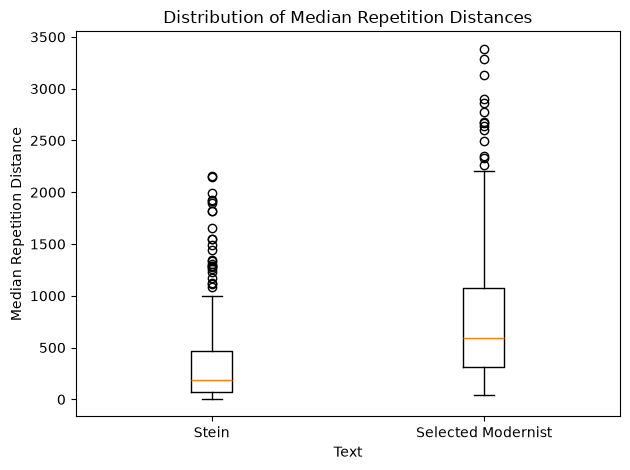

In [192]:
plt.boxplot(
    [
        stein_ordinary_shared_df[
            "median_distance_stein"
        ].dropna(),

        stein_ordinary_shared_df[
            "median_distance_ordinary_modern"
        ].dropna()
    ],
    tick_labels=[
        "Stein",
        "Selected Modernist"
    ]
)

plt.title(
    "Distribution of Median Repetition Distances"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.tight_layout()
plt.show()

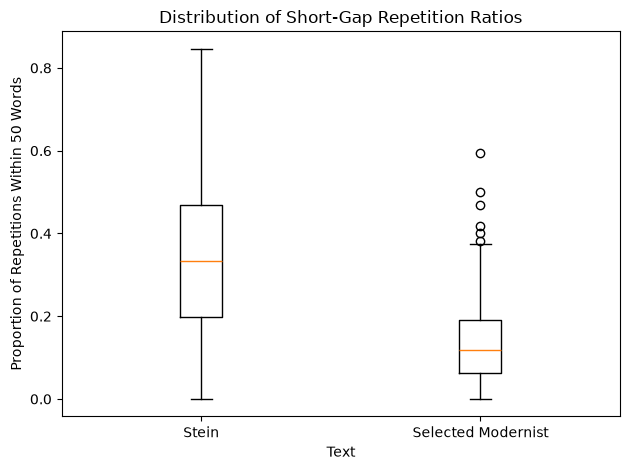

In [193]:
plt.boxplot(
    [
        stein_ordinary_shared_df[
            "short_gap_ratio_50_stein"
        ].dropna(),

        stein_ordinary_shared_df[
            "short_gap_ratio_50_ordinary_modern"
        ].dropna()
    ],
    tick_labels=[
        "Stein",
        "Selected Modernist"
    ]
)

plt.title(
    "Distribution of Short-Gap Repetition Ratios"
)

plt.xlabel("Text")
plt.ylabel(
    "Proportion of Repetitions Within 50 Words"
)

plt.tight_layout()
plt.show()

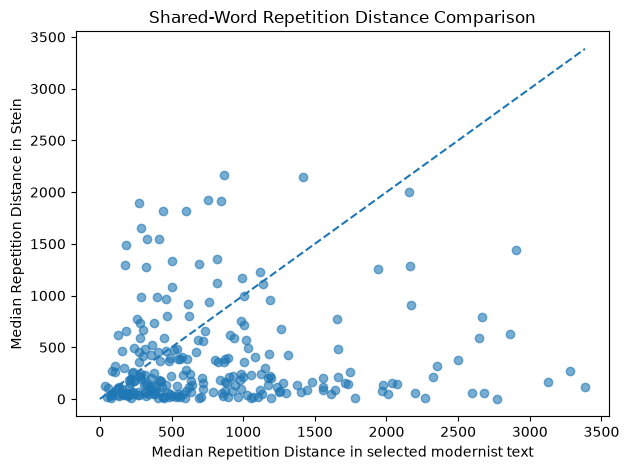

In [194]:
plt.scatter(
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ],
    stein_ordinary_shared_df[
        "median_distance_stein"
    ],
    alpha=0.6
)

maximum_distance = max(
    stein_ordinary_shared_df[
        "median_distance_stein"
    ].max(),

    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ].max()
)

plt.plot(
    [0, maximum_distance],
    [0, maximum_distance],
    linestyle="--"
)

plt.xlabel(
    "Median Repetition Distance in selected modernist text"
)

plt.ylabel(
    "Median Repetition Distance in Stein"
)

plt.title(
    "Shared-Word Repetition Distance Comparison"
)

plt.tight_layout()
plt.show()

In [195]:
stein_shared_median_distance_modern = (
    stein_ordinary_shared_summary_df.loc[
        "Stein",
        "median_repetition_distance"
    ]
)

ordinary_modern_shared_median_distance = (
    stein_ordinary_shared_summary_df.loc[
        "Selected Modernist",
        "median_repetition_distance"
    ]
)

stein_shared_short_gap_modern = (
    stein_ordinary_shared_summary_df.loc[
        "Stein",
        "median_short_gap_ratio_50"
    ]
)

ordinary_modern_shared_short_gap = (
    stein_ordinary_shared_summary_df.loc[
        "Selected Modernist",
        "median_short_gap_ratio_50"
    ]
)

print("RESULT SUMMARY")
print()

print(
    "The analysis compared",
    len(stein_ordinary_shared_df),
    "word types that appeared at least ten times",
    "in both equal-length text samples."
)

print()

print(
    "The median repetition distance was",
    round(
        stein_shared_median_distance_modern,
        2
    ),
    "for Stein and",
    round(
        ordinary_modern_shared_median_distance,
        2
    ),
    "for the selected modernist text."
)

print()

print(
    "The median short-gap ratio was",
    round(
        stein_shared_short_gap_modern,
        3
    ),
    "for Stein and",
    round(
        ordinary_modern_shared_short_gap,
        3
    ),
    "for the selected modernist text."
)

print()

print(
    round(stein_shorter_percentage, 2),
    "% of the shared high-frequency words",
    "repeated sooner in Stein."
)

RESULT SUMMARY

The analysis compared 251 word types that appeared at least ten times in both equal-length text samples.

The median repetition distance was 183.0 for Stein and 592.0 for the selected modernist text.

The median short-gap ratio was 0.333 for Stein and 0.118 for the selected modernist text.

78.88 % of the shared high-frequency words repeated sooner in Stein.


## Stein and the Selected Modernist Text

The two samples share 251 words that occur at least ten times in each. For 78.88% of these words, the median repetition distance is shorter in Stein.

The median repetition distance is 183 content words for Stein and 592 for the selected modernist text. Stein also has a higher median short-gap ratio: 0.333 compared with 0.118.

In this pair of texts, Stein therefore repeats shared high-frequency vocabulary more locally. Since the comparison includes only two works, I cannot treat this result as a general difference between Stein and all other modernist writers.

# Corpus-Level Feature Extraction

The earlier sections tested repetition measurements through comparisons between individual works. I now apply the same preprocessing and feature extraction to the available modernist and nonmodernist corpus files.

Each included work becomes one row in the dataset. This section prepares document-level features for later classification, but it does not yet evaluate a classifier.

In [196]:
from pathlib import Path

modern_folder = Path(
    "ctl-modernist-fiction"
)

nonmodern_folder = Path(
    "1895-1926-ctl-american-non-modernist"
)

modern_files = sorted(
    modern_folder.glob("*.txt")
)

nonmodern_files = sorted(
    nonmodern_folder.glob("*.txt")
)

print(
    "Modernist files:",
    len(modern_files)
)

print(
    "Nonmodernist files:",
    len(nonmodern_files)
)

print()

print("First five modernist files:")

for file_path in modern_files[:5]:
    print(file_path.name)

print()

print("First five nonmodernist files:")

for file_path in nonmodern_files[:5]:
    print(file_path.name)

Modernist files: 41
Nonmodernist files: 984

First five modernist files:
clean00001261.txt
clean00001690.txt
clean00001828.txt
clean00001884.txt
clean00002304.txt

First five nonmodernist files:
clean00001142.txt
clean00001156.txt
clean00001160.txt
clean00001161.txt
clean00001162.txt


## Fixed-Length Samples

Text length affects lexical diversity and repetition measurements. I therefore use the first 10,000 cleaned content words from each work and exclude texts that contain fewer than 10,000.

This keeps sample length consistent, but it also means that longer works are represented only by their opening sections.

In [197]:
def remove_possible_front_matter(text):
    markers = [
        "CHAPTER I",
        "Chapter I",
        "CHAPTER ONE",
        "Chapter One"
    ]

    starts = []

    for marker in markers:
        position = text.find(marker)

        if position != -1:
            starts.append(position)

    if not starts:
        return text

    earliest_start = min(starts)

    # Only remove material if the chapter marker is near the beginning.
    if earliest_start <= len(text) * 0.15:
        return text[earliest_start:]

    return text

In [198]:
def preprocess_corpus_text(text, stop_words):
    text = remove_possible_front_matter(text)
    tokens = word_tokenize(text)

    words = [
        token.lower()
        for token in tokens
        if token.isalpha()
    ]

    content_words = [
        word
        for word in words
        if word not in stop_words
    ]

    return content_words

In [199]:
test_file = modern_files[0]

test_text = test_file.read_text(
    encoding="utf-8",
    errors="ignore"
)

test_words = preprocess_corpus_text(
    test_text,
    stop_words
)

print(
    "Test filename:",
    test_file.name
)

print(
    "Number of cleaned content words:",
    len(test_words)
)

print()

print(
    "First 30 cleaned words:"
)

print(
    test_words[:30]
)

Test filename: clean00001261.txt
Number of cleaned content words: 37783

First 30 cleaned words:
['chapter', 'day', 'november', 'wintry', 'morning', 'close', 'sun', 'shining', 'faint', 'red', 'light', 'fog', 'great', 'noise', 'baying', 'dogs', 'loud', 'voices', 'trampling', 'horses', 'wildairs', 'hall', 'sir', 'jeoffry', 'go', 'forth', 'man', 'choleric', 'temper', 'big']


In [200]:
def corpus_repetition_features(
    words,
    min_occurrences=5,
    short_gap_threshold=50
):
    total_words = len(words)

    if total_words == 0:
        return None

    frequency_distribution = FreqDist(words)
    unique_words = len(frequency_distribution)
    positions = get_word_positions(words)

    repeated_word_frequencies = []

    all_repetition_distances = []

    for word, word_positions in positions.items():

        if len(word_positions) >= min_occurrences:

            repeated_word_frequencies.append(
                len(word_positions)
            )

            distances = repetition_distances(
                word_positions
            )

            all_repetition_distances.extend(
                distances
            )

    type_token_ratio = (
        unique_words / total_words
    )

    lexical_repetition_ratio = (
        1 - type_token_ratio
    )

    hapax_count = sum(
        frequency == 1
        for frequency
        in frequency_distribution.values()
    )

    hapax_ratio = (
        hapax_count / unique_words
        if unique_words > 0
        else np.nan
    )

    repeated_vocabulary_size = len(
        repeated_word_frequencies
    )

    repeated_vocabulary_ratio = (
        repeated_vocabulary_size / unique_words
        if unique_words > 0
        else np.nan
    )

    if len(repeated_word_frequencies) > 0:

        mean_frequency_repeated_words = (
            statistics.mean(
                repeated_word_frequencies
            )
        )

    else:
        mean_frequency_repeated_words = np.nan

    if len(all_repetition_distances) > 0:

        median_repetition_distance = (
            statistics.median(
                all_repetition_distances
            )
        )

        mean_repetition_distance = (
            statistics.mean(
                all_repetition_distances
            )
        )

        short_gap_count = sum(
            distance <= short_gap_threshold
            for distance
            in all_repetition_distances
        )

        short_gap_ratio_50 = (
            short_gap_count
            /
            len(all_repetition_distances)
        )

    else:
        median_repetition_distance = np.nan
        mean_repetition_distance = np.nan
        short_gap_ratio_50 = np.nan

    if len(all_repetition_distances) >= 2:

        repetition_distance_std = (
            statistics.stdev(
                all_repetition_distances
            )
        )

        if mean_repetition_distance != 0:

            repetition_distance_cv = (
                repetition_distance_std
                /
                mean_repetition_distance
            )

        else:
            repetition_distance_cv = np.nan

    else:
        repetition_distance_std = np.nan
        repetition_distance_cv = np.nan

    return {
        "total_words": total_words,

        "unique_words": unique_words,

        "type_token_ratio":
            type_token_ratio,

        "lexical_repetition_ratio":
            lexical_repetition_ratio,

        "hapax_ratio":
            hapax_ratio,

        "repeated_vocabulary_size":
            repeated_vocabulary_size,

        "repeated_vocabulary_ratio":
            repeated_vocabulary_ratio,

        "mean_frequency_repeated_words":
            mean_frequency_repeated_words,

        "median_repetition_distance":
            median_repetition_distance,

        "mean_repetition_distance":
            mean_repetition_distance,

        "short_gap_ratio_50":
            short_gap_ratio_50,

        "repetition_distance_std":
            repetition_distance_std,

        "repetition_distance_cv":
            repetition_distance_cv
    }

In [201]:
test_sample_words = test_words[
    :10000
]

test_features = corpus_repetition_features(
    test_sample_words
)

test_features

{'total_words': 10000,
 'unique_words': 3110,
 'type_token_ratio': 0.311,
 'lexical_repetition_ratio': 0.6890000000000001,
 'hapax_ratio': 0.5482315112540193,
 'repeated_vocabulary_size': 470,
 'repeated_vocabulary_ratio': 0.15112540192926044,
 'mean_frequency_repeated_words': 12.52127659574468,
 'median_repetition_distance': 252,
 'mean_repetition_distance': 614.002216066482,
 'short_gap_ratio_50': 0.192797783933518,
 'repetition_distance_std': 907.8827228304336,
 'repetition_distance_cv': 1.4786310196836998}

In [202]:
DOCUMENT_SAMPLE_SIZE = 10000

def process_corpus_file(file_path, label, sample_size=DOCUMENT_SAMPLE_SIZE):

    try:
        text = file_path.read_text(
            encoding="utf-8",
            errors="ignore"
        )

        words = preprocess_corpus_text(
            text,
            stop_words
        )

        original_content_word_count = len(
            words
        )

        if original_content_word_count < sample_size:

            return {
                "status": "skipped",
                "filename": file_path.name,
                "label": label,
                "original_content_word_count":
                    original_content_word_count,
                "reason": "fewer than required content words"
            }

        sample_words = words[
            :sample_size
        ]

        features = corpus_repetition_features(
            sample_words
        )

        features["filename"] = (
            file_path.name
        )

        features["label"] = label

        features[
            "original_content_word_count"
        ] = original_content_word_count

        features["status"] = "included"

        return features

    except Exception as error:

        return {
            "status": "error",
            "filename": file_path.name,
            "label": label,
            "reason": str(error)
        }

In [203]:
single_file_result = process_corpus_file(
    modern_files[0],
    label="modern"
)

single_file_result

{'total_words': 10000,
 'unique_words': 3110,
 'type_token_ratio': 0.311,
 'lexical_repetition_ratio': 0.6890000000000001,
 'hapax_ratio': 0.5482315112540193,
 'repeated_vocabulary_size': 470,
 'repeated_vocabulary_ratio': 0.15112540192926044,
 'mean_frequency_repeated_words': 12.52127659574468,
 'median_repetition_distance': 252,
 'mean_repetition_distance': 614.002216066482,
 'short_gap_ratio_50': 0.192797783933518,
 'repetition_distance_std': 907.8827228304336,
 'repetition_distance_cv': 1.4786310196836998,
 'filename': 'clean00001261.txt',
 'label': 'modern',
 'original_content_word_count': 37783,
 'status': 'included'}

In [204]:
modern_corpus_results = []

for file_number, file_path in enumerate(
    modern_files,
    start=1
):

    result = process_corpus_file(
        file_path,
        label="modern"
    )

    modern_corpus_results.append(
        result
    )

    print(
        f"Modern {file_number}/{len(modern_files)}:",
        file_path.name,
        result["status"]
    )

Modern 1/41: clean00001261.txt included
Modern 2/41: clean00001690.txt included
Modern 3/41: clean00001828.txt included
Modern 4/41: clean00001884.txt included
Modern 5/41: clean00002304.txt included
Modern 6/41: clean00002437.txt included
Modern 7/41: clean00002725.txt skipped
Modern 8/41: clean00002948.txt included
Modern 9/41: clean00002949.txt skipped
Modern 10/41: clean00003082.txt included
Modern 11/41: clean00003083.txt included
Modern 12/41: clean00003352.txt included
Modern 13/41: clean00003439.txt included
Modern 14/41: clean00003681.txt included
Modern 15/41: clean00003713.txt included
Modern 16/41: clean00003812.txt included
Modern 17/41: clean00003814.txt included
Modern 18/41: clean00004171.txt included
Modern 19/41: clean00004292.txt included
Modern 20/41: clean00004412.txt included
Modern 21/41: clean00004414.txt included
Modern 22/41: clean00004415.txt included
Modern 23/41: clean00004431.txt included
Modern 24/41: clean00004506.txt included
Modern 25/41: clean00004530

In [205]:
nonmodern_corpus_results = []

for file_number, file_path in enumerate(
    nonmodern_files,
    start=1
):

    result = process_corpus_file(
        file_path,
        label="nonmodern"
    )

    nonmodern_corpus_results.append(
        result
    )

    print(
        f"Nonmodern {file_number}/{len(nonmodern_files)}:",
        file_path.name,
        result["status"]
    )

Nonmodern 1/984: clean00001142.txt included
Nonmodern 2/984: clean00001156.txt included
Nonmodern 3/984: clean00001160.txt included
Nonmodern 4/984: clean00001161.txt included
Nonmodern 5/984: clean00001162.txt included
Nonmodern 6/984: clean00001176.txt included
Nonmodern 7/984: clean00001177.txt included
Nonmodern 8/984: clean00001180.txt skipped
Nonmodern 9/984: clean00001185.txt included
Nonmodern 10/984: clean00001186.txt included
Nonmodern 11/984: clean00001192.txt included
Nonmodern 12/984: clean00001196.txt included
Nonmodern 13/984: clean00001199.txt included
Nonmodern 14/984: clean00001233.txt included
Nonmodern 15/984: clean00001238.txt skipped
Nonmodern 16/984: clean00001246.txt skipped
Nonmodern 17/984: clean00001250.txt included
Nonmodern 18/984: clean00001255.txt included
Nonmodern 19/984: clean00001259.txt included
Nonmodern 20/984: clean00001273.txt included
Nonmodern 21/984: clean00001283.txt included
Nonmodern 22/984: clean00001285.txt included
Nonmodern 23/984: clea

In [206]:
all_corpus_results = (
    modern_corpus_results
    +
    nonmodern_corpus_results
)

included_results = [
    result
    for result in all_corpus_results
    if result["status"] == "included"
]

skipped_results = [
    result
    for result in all_corpus_results
    if result["status"] == "skipped"
]

error_results = [
    result
    for result in all_corpus_results
    if result["status"] == "error"
]

print(
    "Included texts:",
    len(included_results)
)

print(
    "Skipped texts:",
    len(skipped_results)
)

print(
    "Error texts:",
    len(error_results)
)

Included texts: 941
Skipped texts: 84
Error texts: 0


In [207]:
skipped_results[:10]

[{'status': 'skipped',
  'filename': 'clean00002725.txt',
  'label': 'modern',
  'original_content_word_count': 8673,
  'reason': 'fewer than required content words'},
 {'status': 'skipped',
  'filename': 'clean00002949.txt',
  'label': 'modern',
  'original_content_word_count': 8593,
  'reason': 'fewer than required content words'},
 {'status': 'skipped',
  'filename': 'clean00001180.txt',
  'label': 'nonmodern',
  'original_content_word_count': 7208,
  'reason': 'fewer than required content words'},
 {'status': 'skipped',
  'filename': 'clean00001238.txt',
  'label': 'nonmodern',
  'original_content_word_count': 4286,
  'reason': 'fewer than required content words'},
 {'status': 'skipped',
  'filename': 'clean00001246.txt',
  'label': 'nonmodern',
  'original_content_word_count': 9643,
  'reason': 'fewer than required content words'},
 {'status': 'skipped',
  'filename': 'clean00001297.txt',
  'label': 'nonmodern',
  'original_content_word_count': 5031,
  'reason': 'fewer than requir

In [208]:
error_results[:10]

[]

In [209]:
corpus_features_df = pd.DataFrame(
    included_results
)

corpus_features_df.head()

,total_words,unique_words,type_token_ratio,lexical_repetition_ratio,hapax_ratio,repeated_vocabulary_size,repeated_vocabulary_ratio,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance,short_gap_ratio_50,repetition_distance_std,repetition_distance_cv,filename,label,original_content_word_count,status
0,10000,3110,0.3110,0.6890,0.548232,470,0.151125,12.521277,252.0,614.002216,0.192798,907.882723,1.478631,clean00001261.txt,modern,37783,included
1,10000,3119,0.3119,0.6881,0.552421,473,0.151651,12.469345,242.0,615.479447,0.224885,940.811463,1.528583,clean00001690.txt,modern,59105,included
2,10000,3638,0.3638,0.6362,0.622595,456,0.125344,11.842105,262.5,626.056230,0.210761,923.738105,1.475487,clean00001828.txt,modern,23776,included
3,10000,3241,0.3241,0.6759,0.568652,445,0.137303,12.788764,240.0,610.039268,0.224171,896.072324,1.468876,clean00001884.txt,modern,71473,included
4,10000,4124,0.4124,0.5876,0.613967,410,0.099418,10.895122,313.0,702.358393,0.170076,975.671483,1.389136,clean00002304.txt,modern,72669,included


In [210]:
print(
    "Dataset shape:",
    corpus_features_df.shape
)

print()

print(
    corpus_features_df[
        "label"
    ].value_counts()
)

Dataset shape: (941, 17)

label
nonmodern    902
modern        39
Name: count, dtype: int64


In [211]:
metadata_columns = [
    "filename",
    "label",
    "status",
    "original_content_word_count",
    "total_words"
]

feature_columns = [
    "unique_words",
    "type_token_ratio",
    "lexical_repetition_ratio",
    "hapax_ratio",
    "repeated_vocabulary_size",
    "repeated_vocabulary_ratio",
    "mean_frequency_repeated_words",
    "median_repetition_distance",
    "mean_repetition_distance",
    "short_gap_ratio_50",
    "repetition_distance_std",
    "repetition_distance_cv"
]

corpus_features_df = corpus_features_df[
    metadata_columns
    +
    feature_columns
]

corpus_features_df.head()

,filename,label,status,original_content_word_count,total_words,unique_words,type_token_ratio,lexical_repetition_ratio,hapax_ratio,repeated_vocabulary_size,repeated_vocabulary_ratio,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance,short_gap_ratio_50,repetition_distance_std,repetition_distance_cv
0,clean00001261.txt,modern,included,37783,10000,3110,0.3110,0.6890,0.548232,470,0.151125,12.521277,252.0,614.002216,0.192798,907.882723,1.478631
1,clean00001690.txt,modern,included,59105,10000,3119,0.3119,0.6881,0.552421,473,0.151651,12.469345,242.0,615.479447,0.224885,940.811463,1.528583
2,clean00001828.txt,modern,included,23776,10000,3638,0.3638,0.6362,0.622595,456,0.125344,11.842105,262.5,626.056230,0.210761,923.738105,1.475487
3,clean00001884.txt,modern,included,71473,10000,3241,0.3241,0.6759,0.568652,445,0.137303,12.788764,240.0,610.039268,0.224171,896.072324,1.468876
4,clean00002304.txt,modern,included,72669,10000,4124,0.4124,0.5876,0.613967,410,0.099418,10.895122,313.0,702.358393,0.170076,975.671483,1.389136


In [212]:
corpus_features_df[
    feature_columns
].isna().sum()

unique_words                     0
type_token_ratio                 0
lexical_repetition_ratio         0
hapax_ratio                      0
repeated_vocabulary_size         0
repeated_vocabulary_ratio        0
mean_frequency_repeated_words    0
median_repetition_distance       0
mean_repetition_distance         0
short_gap_ratio_50               0
repetition_distance_std          0
repetition_distance_cv           0
dtype: int64

In [213]:
corpus_features_df.to_csv(
    "corpus_repetition_features.csv",
    index=False
)

print(
    "Saved corpus_repetition_features.csv"
)

Saved corpus_repetition_features.csv


In [214]:
corpus_group_medians = (
    corpus_features_df
    .groupby("label")[
        feature_columns
    ]
    .median()
)

corpus_group_medians.T

label,modern,nonmodern
unique_words,3525.000000,3269.500000
type_token_ratio,0.352500,0.326950
lexical_repetition_ratio,0.647500,0.673050
hapax_ratio,0.602123,0.574609
repeated_vocabulary_size,438.000000,448.500000
repeated_vocabulary_ratio,0.123562,0.137617
mean_frequency_repeated_words,12.469345,12.567195
median_repetition_distance,244.000000,230.000000
mean_repetition_distance,614.002216,606.379891
short_gap_ratio_50,0.224885,0.236520


In [215]:
important_features = [
    "type_token_ratio",
    "repeated_vocabulary_ratio",
    "mean_frequency_repeated_words",
    "median_repetition_distance",
    "short_gap_ratio_50",
    "repetition_distance_cv"
]

corpus_group_medians[
    important_features
].T

label,modern,nonmodern
type_token_ratio,0.352500,0.326950
repeated_vocabulary_ratio,0.123562,0.137617
mean_frequency_repeated_words,12.469345,12.567195
median_repetition_distance,244.000000,230.000000
short_gap_ratio_50,0.224885,0.236520
repetition_distance_cv,1.499202,1.521974


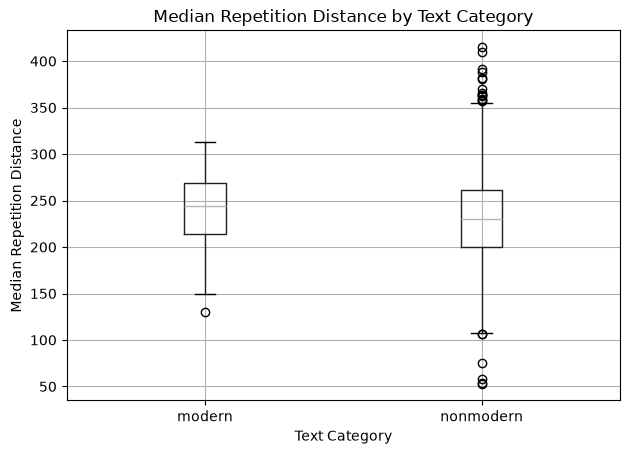

In [216]:
corpus_features_df.boxplot(
    column="median_repetition_distance",
    by="label"
)

plt.title(
    "Median Repetition Distance by Text Category"
)

plt.suptitle("")

plt.xlabel("Text Category")

plt.ylabel(
    "Median Repetition Distance"
)

plt.tight_layout()

plt.show()

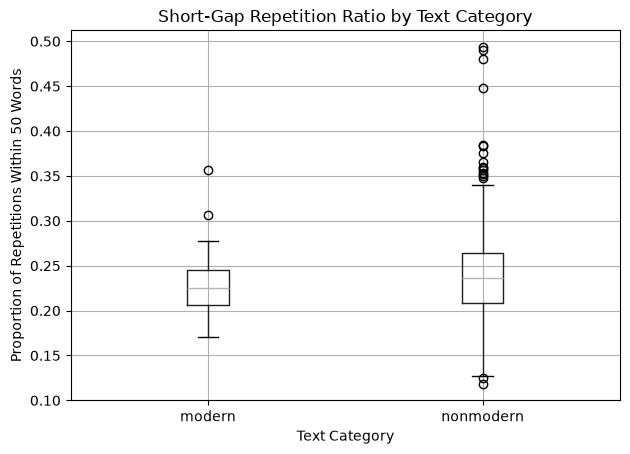

In [217]:
corpus_features_df.boxplot(
    column="short_gap_ratio_50",
    by="label"
)

plt.title(
    "Short-Gap Repetition Ratio by Text Category"
)

plt.suptitle("")

plt.xlabel("Text Category")

plt.ylabel(
    "Proportion of Repetitions Within 50 Words"
)

plt.tight_layout()

plt.show()

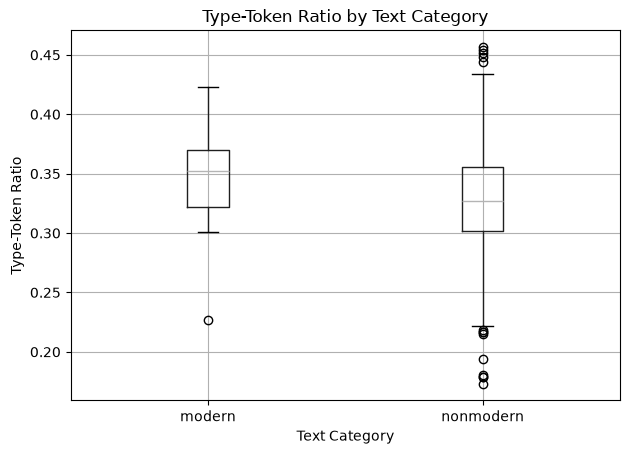

In [218]:
corpus_features_df.boxplot(
    column="type_token_ratio",
    by="label"
)

plt.title(
    "Type-Token Ratio by Text Category"
)

plt.suptitle("")

plt.xlabel("Text Category")

plt.ylabel(
    "Type-Token Ratio"
)

plt.tight_layout()

plt.show()

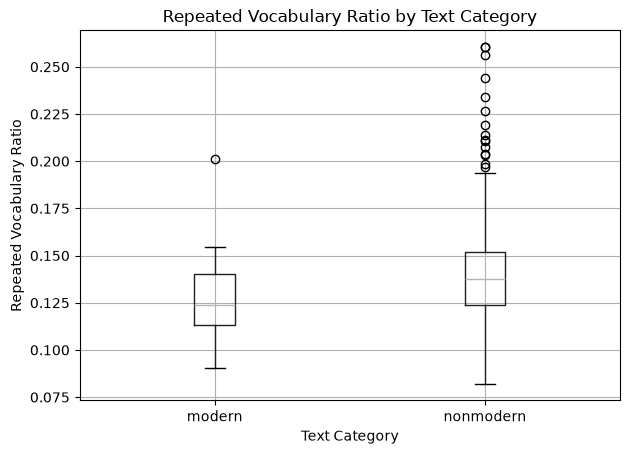

In [219]:
corpus_features_df.boxplot(
    column="repeated_vocabulary_ratio",
    by="label"
)

plt.title(
    "Repeated Vocabulary Ratio by Text Category"
)

plt.suptitle("")

plt.xlabel("Text Category")

plt.ylabel(
    "Repeated Vocabulary Ratio"
)

plt.tight_layout()

plt.show()

# Corpus-Level Results

The final table contains one row for each included literary work. I first check the number of texts in each category, missing values, and the distribution of the repetition features.

These summaries show how the extracted features differ across the available corpus, but they do not by themselves show whether the features can classify unseen texts.

In [220]:
corpus_summary = (
    corpus_features_df
    .groupby("label")[
        feature_columns
    ]
    .agg(
        [
            "median",
            "mean",
            "std"
        ]
    )
)

corpus_summary

unique_words                          type_token_ratio            \
                median         mean         std           median      mean   
label                                                                        
modern          3525.0  3504.923077  398.119751          0.35250  0.350492   
nonmodern       3269.5  3287.977827  421.385666          0.32695  0.328798   

                    lexical_repetition_ratio                     hapax_ratio  \
                std                   median      mean       std      median   
label                                                                          
modern     0.039812                  0.64750  0.649508  0.039812    0.602123   
nonmodern  0.042139                  0.67305  0.671202  0.042139    0.574609   

           ... mean_repetition_distance short_gap_ratio_50            \
           ...                      std             median      mean   
label      ...                                                         
modern     ...                47.334821           0.224885  0.229170   
nonmodern  ...                61.778364           0.236520  0.238281   

                    repetition_distance_std                         \
                std                  median        mean        std   
label                                                                
modern     0.036391              918.452237  918.739191  31.297565   
nonmodern  0.046193              926.796795  925.702205  52.137838   

          repetition_distance_cv                      
                          median      mean       std  
label                                                 
modern                  1.499202  1.506112  0.087705  
nonmodern               1.521974  1.530018  0.104127  

[2 rows x 36 columns]

In [221]:
important_summary = (
    corpus_features_df
    .groupby("label")[
        important_features
    ]
    .agg(
        [
            "median",
            "mean",
            "std"
        ]
    )
)

important_summary.T

label                                     modern   nonmodern
type_token_ratio              median    0.352500    0.326950
                              mean      0.350492    0.328798
                              std       0.039812    0.042139
repeated_vocabulary_ratio     median    0.123562    0.137617
                              mean      0.126107    0.139162
                              std       0.021648    0.023072
mean_frequency_repeated_words median   12.469345   12.567195
                              mean     12.514149   12.680598
                              std       0.947398    1.283299
median_repetition_distance    median  244.000000  230.000000
                              mean    241.397436  232.696231
                              std      39.208649   50.746413
short_gap_ratio_50            median    0.224885    0.236520
                              mean      0.229170    0.238281
                              std       0.036391    0.046193
repetition_distance_cv        median    1.499202    1.521974
                              mean      1.506112    1.530018
                              std       0.087705    0.104127

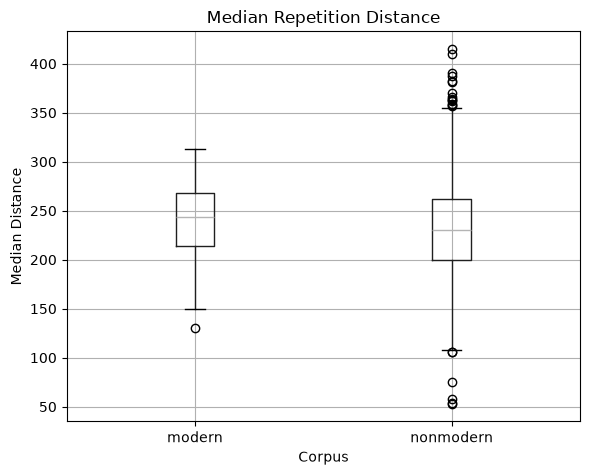

In [222]:
corpus_features_df.boxplot(
    column="median_repetition_distance",
    by="label",
    figsize=(6,5)
)

plt.title(
    "Median Repetition Distance"
)

plt.suptitle("")

plt.xlabel("Corpus")

plt.ylabel("Median Distance")

plt.tight_layout()

plt.show()

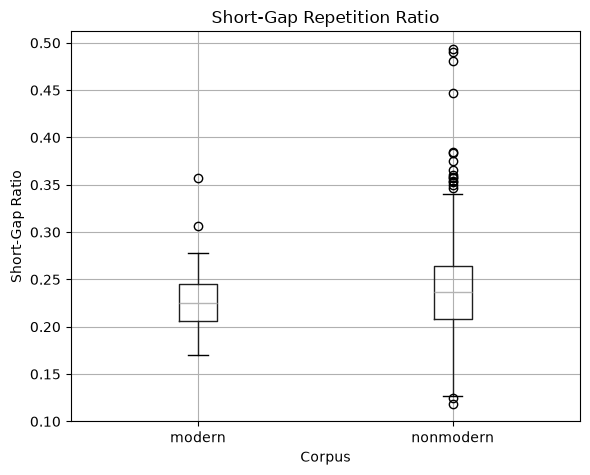

In [223]:
corpus_features_df.boxplot(
    column="short_gap_ratio_50",
    by="label",
    figsize=(6,5)
)

plt.title(
    "Short-Gap Repetition Ratio"
)

plt.suptitle("")

plt.xlabel("Corpus")

plt.ylabel("Short-Gap Ratio")

plt.tight_layout()

plt.show()

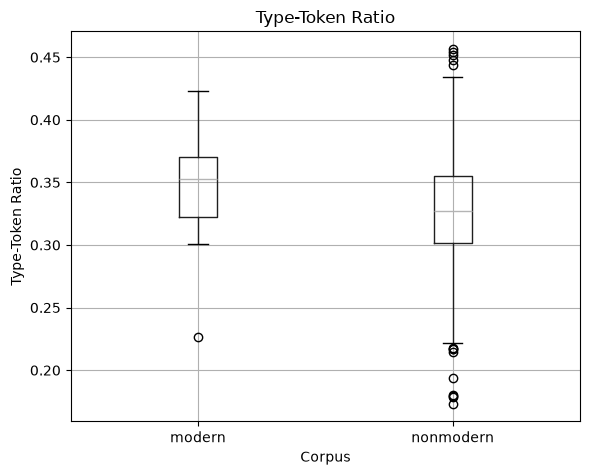

In [224]:
corpus_features_df.boxplot(
    column="type_token_ratio",
    by="label",
    figsize=(6,5)
)

plt.title(
    "Type-Token Ratio"
)

plt.suptitle("")

plt.xlabel("Corpus")

plt.ylabel("Type-Token Ratio")

plt.tight_layout()

plt.show()

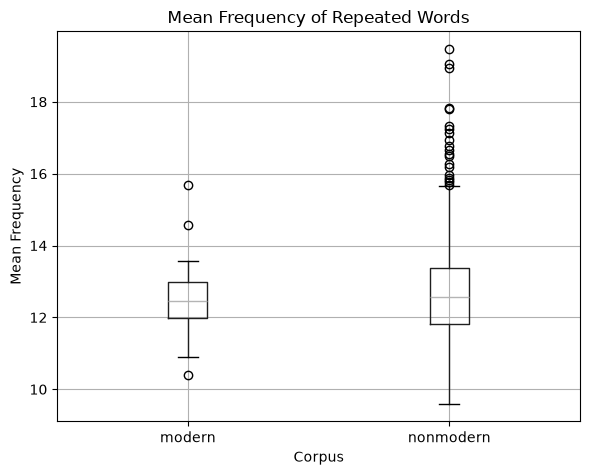

In [225]:
corpus_features_df.boxplot(
    column="mean_frequency_repeated_words",
    by="label",
    figsize=(6,5)
)

plt.title(
    "Mean Frequency of Repeated Words"
)

plt.suptitle("")

plt.xlabel("Corpus")

plt.ylabel("Mean Frequency")

plt.tight_layout()

plt.show()

In [226]:
correlation_matrix = corpus_features_df[
    feature_columns
].corr()

correlation_matrix

,unique_words,type_token_ratio,lexical_repetition_ratio,hapax_ratio,repeated_vocabulary_size,repeated_vocabulary_ratio,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance,short_gap_ratio_50,repetition_distance_std,repetition_distance_cv
unique_words,1.000000,1.000000,-1.000000,0.845741,-0.390533,-0.937021,-0.815987,0.614974,0.757218,-0.460449,0.725110,-0.551210
type_token_ratio,1.000000,1.000000,-1.000000,0.845741,-0.390533,-0.937021,-0.815987,0.614974,0.757218,-0.460449,0.725110,-0.551210
lexical_repetition_ratio,-1.000000,-1.000000,1.000000,-0.845741,0.390533,0.937021,0.815987,-0.614974,-0.757218,0.460449,-0.725110,0.551210
hapax_ratio,0.845741,0.845741,-0.845741,1.000000,-0.639781,-0.923217,-0.454751,0.321837,0.411802,-0.200595,0.411275,-0.283204
repeated_vocabulary_size,-0.390533,-0.390533,0.390533,-0.639781,1.000000,0.615244,-0.194956,0.172658,0.156729,-0.256778,0.097074,-0.199541
repeated_vocabulary_ratio,-0.937021,-0.937021,0.937021,-0.923217,0.615244,1.000000,0.607966,-0.432631,-0.556453,0.289873,-0.552758,0.386489
mean_frequency_repeated_words,-0.815987,-0.815987,0.815987,-0.454751,-0.194956,0.607966,1.000000,-0.765845,-0.912173,0.661235,-0.842485,0.722185
median_repetition_distance,0.614974,0.614974,-0.614974,0.321837,0.172658,-0.432631,-0.765845,1.000000,0.921993,-0.925876,0.545384,-0.943773
mean_repetition_distance,0.757218,0.757218,-0.757218,0.411802,0.156729,-0.556453,-0.912173,0.921993,1.000000,-0.809431,0.803970,-0.861050
short_gap_ratio_50,-0.460449,-0.460449,0.460449,-0.200595,-0.256778,0.289873,0.661235,-0.925876,-0.809431,1.000000,-0.412662,0.914276


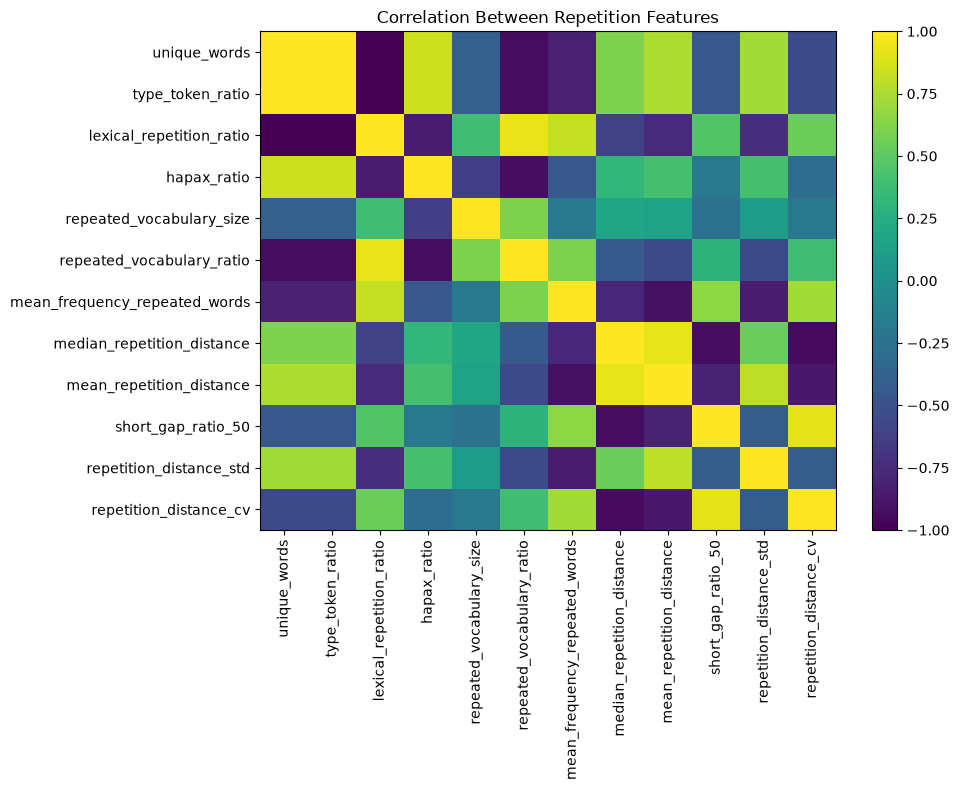

In [227]:
plt.figure(figsize=(10,8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title(
    "Correlation Between Repetition Features"
)

plt.tight_layout()

plt.show()

In [228]:
corpus_features_df.sort_values(
    by="median_repetition_distance"
)[
    [
        "filename",
        "label",
        "median_repetition_distance"
    ]
].head(10)

,filename,label,median_repetition_distance
102,clean00001566.txt,nonmodern,53.0
120,clean00001719.txt,nonmodern,54.0
189,clean00002203.txt,nonmodern,58.0
209,clean00002262.txt,nonmodern,75.0
371,clean00002969.txt,nonmodern,106.0
779,clean00004406.txt,nonmodern,106.0
627,clean00003843.txt,nonmodern,108.0
844,clean00004631.txt,nonmodern,112.0
631,clean00003856.txt,nonmodern,115.0
521,clean00003489.txt,nonmodern,117.0


In [229]:
corpus_features_df.sort_values(
    by="short_gap_ratio_50",
    ascending=False
)[
    [
        "filename",
        "label",
        "short_gap_ratio_50"
    ]
].head(10)

,filename,label,short_gap_ratio_50
102,clean00001566.txt,nonmodern,0.493453
120,clean00001719.txt,nonmodern,0.490554
189,clean00002203.txt,nonmodern,0.480601
209,clean00002262.txt,nonmodern,0.447406
371,clean00002969.txt,nonmodern,0.384354
779,clean00004406.txt,nonmodern,0.383827
627,clean00003843.txt,nonmodern,0.375644
844,clean00004631.txt,nonmodern,0.365767
521,clean00003489.txt,nonmodern,0.360128
895,clean00010210.txt,nonmodern,0.358725


In [230]:
corpus_features_df.sort_values(
    by="type_token_ratio"
)[
    [
        "filename",
        "label",
        "type_token_ratio"
    ]
].head(10)

,filename,label,type_token_ratio
779,clean00004406.txt,nonmodern,0.1732
631,clean00003856.txt,nonmodern,0.1787
797,clean00004483.txt,nonmodern,0.1791
598,clean00003771.txt,nonmodern,0.1801
696,clean00004083.txt,nonmodern,0.1938
926,clean00010248.txt,nonmodern,0.2146
785,clean00004422.txt,nonmodern,0.2167
583,clean00003707.txt,nonmodern,0.2169
793,clean00004464.txt,nonmodern,0.2181
569,clean00003623.txt,nonmodern,0.2216


In [231]:
corpus_features_df.to_csv(
    "corpus_repetition_features.csv",
    index=False
)

print(
    "Corpus feature table saved."
)

Corpus feature table saved.


# Conclusion

This notebook began by measuring the positions and distances of selected repeated words. I then converted these measurements into text-level features and applied them to the available corpus.

The pairwise comparisons suggest that Stein repeats many shared high-frequency words more locally than the two selected comparison texts. These results describe the works included in the case studies and should not yet be generalized to all modernist writing.

The corpus-level dataset contains far more nonmodernist works than modernist works, so class imbalance must be addressed before evaluating a classifier. My next step is to test a simple classifier while accounting for the large class imbalance. I also plan to compare the repetition features with a basic TF-IDF model.

In [232]:
print("Number of texts:", len(corpus_features_df))
print()

print(corpus_features_df["label"].value_counts())
print()

print("Number of repetition features:", len(feature_columns))

Number of texts: 941

label
nonmodern    902
modern        39
Name: count, dtype: int64

Number of repetition features: 12
